# Machine Learning–Based Prediction of Capital Bikeshare Usage in Washington, D.C.


# Table of Content

- [1. Introduction](#1-introduction)
  - [1.1 Problem Statement](#11-problem-statement)
  - [1.2 Dataset](#12-dataset)
- [2. Methodology](#2-methodology)
  - [2.1 Data Preprocessing](#21-data-preprocessing)
  - [2.2 Data Analysis](#22-data-analysis)
- [3. Modelling and Optimization](#3-modelling-and-Optimization)
  - [3.1 Linear Regression](#31-Linear-Regression)
  - [3.2 Ridge Regression](#32-Ridge-Regression)
  - [3.3 LASSO Regression](#33-LASSO-Regression)
  - [3.4 Random Forest Regression](#34-Random-Forest-Regression)
- [4. Evaluation](#4-evaluation)
- [5. Conclusion and Future Work](#5-conclusion-and-future-work)

## 1. Introduction



In recent years, bike‑sharing systems have become an increasingly popular, eco‑friendly urban mobility solution. By allowing users to pick up and drop off bicycles at automated stations throughout a city, these systems help reduce traffic congestion, lower carbon emissions, and promote healthy lifestyles.   Beyond their real‑world applications, the unique properties of data generated by bike‑sharing systems also make them highly valuable for research. To effectively managing a bike‑sharing network requires accurate demand forecasting. Operators need to know how many bikes will be rented on any given day in order to redistribute fleets, schedule maintenance and ensure availability.

To accomplish this, this project will focus on modeling and prediction of the daily rental counts for the Capital Bikeshare system in Washington, D.C. We use the publicly available “day.csv” dataset [1], which contains 731 daily observations spanning 2011–2012. Each record includes both environmental factors (e.g., temperature, humidity, wind speed) and temporal variables (season, month, weekday, holiday flags). Our primary goal is to build a regression model that can capture the relationships between these features and the total number of rented bikes, thereby enabling reliable short‑term demand forecasts.

### 1.1 Problem Statement

Using 731 records of daily data from 2011 to 2012 — including various features related to time, weather, and user behavior that may affect rental activity, along with actual bike rental count labels — to predict the daily number of bike rentals in Washington D.C.’s Capital Bikeshare system.

## 1.2 Dataset

In [2]:
# Import Libraries
import os
import sys
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Preprocessing and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso


In [3]:

# Create a dataframe describing each variable
variables = [
    "instant", "dteday", "season", "yr", "mnth", "hr", "holiday",
    "weekday", "workingday", "weathersit", "temp", "atemp", "hum",
    "windspeed", "casual", "registered", "cnt"
]

descriptions = [
    "Record index",
    "Date of the observation",
    "Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)",
    "Year (0: 2011, 1: 2012)",
    "Month (1 to 12)",
    "Hour (0 to 23) – not available in day.csv",
    "Indicator if the day is a holiday (1: holiday, 0: not)",
    "Day of the week (0: Sunday to 6: Saturday)",
    "Indicator if day is working day (1) or weekend/holiday (0)",
    "Weather situation (1: Clear/Few clouds, 2: Mist/Cloudy, 3: Light Snow/Rain, 4: Heavy Rain/Snow)",
    "Normalized temperature in Celsius (divided by 41)",
    "Normalized feeling temperature in Celsius (divided by 50)",
    "Normalized humidity (divided by 100)",
    "Normalized wind speed (divided by 67)",
    "Count of casual users (leisure)",
    "Count of registered users (subscribers)",
    "Total count of bike rentals (casual + registered)"
]

df_variables = pd.DataFrame({
    "Variable": variables,
    "Description": descriptions
})


df_variables.head(18)



,Variable,Description
0,instant,Record index
1,dteday,Date of the observation
2,season,"Season (1: Spring, 2: Summer, 3: Fall, 4: Winter)"
3,yr,"Year (0: 2011, 1: 2012)"
4,mnth,Month (1 to 12)
5,hr,Hour (0 to 23) – not available in day.csv
6,holiday,"Indicator if the day is a holiday (1: holiday,..."
7,weekday,Day of the week (0: Sunday to 6: Saturday)
8,workingday,Indicator if day is working day (1) or weekend...
9,weathersit,"Weather situation (1: Clear/Few clouds, 2: Mis..."


In [4]:
day_bike = pd.read_csv('day.csv')
day_bike.head(10)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [5]:
day_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
# Get basic idea of data using describe()
day_bike.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [7]:
def enhanced_data_overview(df, head_rows=5):
    """
    Display an extended overview of the DataFrame:
    - Shape (rows, columns)
    - Memory usage
    - Missing values (count + percentage)
    - Duplicate rows
    - Data types
    - Number of unique values per column
    - Head (first rows)
    - Descriptive statistics for numeric features
    - Descriptive statistics for categorical features
    """

    
    # 3. Missing Values
    display(Markdown("## Missing Values"))
    missing = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Missing %': (df.isnull().mean() * 100).round(2)
    })
    display(missing)
    
    # 4. Duplicate Rows
    display(Markdown("## Duplicate Rows"))
    dup_count = df.duplicated().sum()
    print(f"Number of duplicate rows: {dup_count}\n")
    
    # 5. Data Types
    display(Markdown("## Data Types"))
    display(pd.DataFrame(df.dtypes, columns=['Dtype']))
    
    # 6. Unique Values Count
    display(Markdown("## Unique Values per Column"))
    unique_counts = pd.DataFrame({
        'Unique Count': df.nunique(),
        'Data Type': df.dtypes
    })
    display(unique_counts)

    # 7. Head (first rows)
    display(Markdown("## Head (First Rows)"))
    display(df.head(head_rows))

    # 8. Bottom (last rows)
    display(Markdown("## Bottom (Last Rows)"))
    display(df.tail(head_rows))

    #9. Descriptive Statistics
    display(Markdown("## Descriptive Statistics"))
    display(df.describe(include='all'))

# Call the function to display the overview
enhanced_data_overview(day_bike, head_rows=5)

## Missing Values

,Missing Count,Missing %
instant,0,0.0
dteday,0,0.0
season,0,0.0
yr,0,0.0
mnth,0,0.0
holiday,0,0.0
weekday,0,0.0
workingday,0,0.0
weathersit,0,0.0
temp,0,0.0


## Duplicate Rows

Number of duplicate rows: 0



## Data Types

...

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Bottom (Last Rows)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


## Descriptive Statistics

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2011-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


# 2. Methodology

# 2.1 Data Preprocessing

In [8]:
def extract_features_categorical(df, cat_th = 13, num_th = 20):
    """
    Extract categorical features from the DataFrame based on thresholds for unique values.
    
    Parameters:
    - df: DataFrame to extract features from
    - cat_th: Threshold for categorical features (default 13)
    - num_th: Threshold for numerical features (default 20)
    
    Returns:
    - cat_cols: List of categorical feature names
    - num_cols: List of numerical feature names
    """
    # 1. Identify 'true' categorical columns
    cat_cols = [col for col in df.columns if df[col].dtype == "O"]

    # 2. Identify numeric columns that should be treated as categorical
    #    because they have fewer than cat_th unique values
    num_but_cat = [
        col for col in df.columns
        if df[col].nunique() < cat_th and df[col].dtypes != "O"
    ]
    # 3. Identify 'categorical but high cardinality' columns
    cat_but_car = [
        col for col in df.columns
        if df[col].nunique() > cat_th and df[col].dtypes == "O"
    ]
    # 4. Combine object-type categorical columns and numeric-but-categorical columns,
    #    then exclude any high-cardinality columns
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # 5. Identify numeric columns (dtype != object), excluding those in num_but_cat
    num_cols = [col for col in df.columns if df[col].dtype != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # 6. Identify binary categorical columns (exactly two unique values)
    binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

    # 7. Identify non-binary categorical columns
    only_cat_cols = list(set(cat_cols) - set(binary_cols))

    
    return cat_cols, num_cols

In [9]:
# Renaming columns for better readability 
day_bike.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'cnt': 'total_count',
    'dteday': 'date',

}, inplace=True)
# Display the first few rows of the modified DataFrame
day_bike.head()

,instant,date,season,year,month,holiday,weekday,workingday,weathersit,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [10]:
categorical_variables, numerical_variables = extract_features_categorical(day_bike, cat_th=13, num_th=20)

# Display the categorical and numerical variables
print("Categorical Variables:")
print(categorical_variables)

print("\nNumerical Variables:")
print(numerical_variables)




Categorical Variables:
['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']

Numerical Variables:
['instant', 'temperature', 'feeling_temperature', 'humidity', 'windspeed', 'casual', 'registered', 'total_count']


# 2.2 Data Analysis

## Descriptive Statistics for Numerical Features

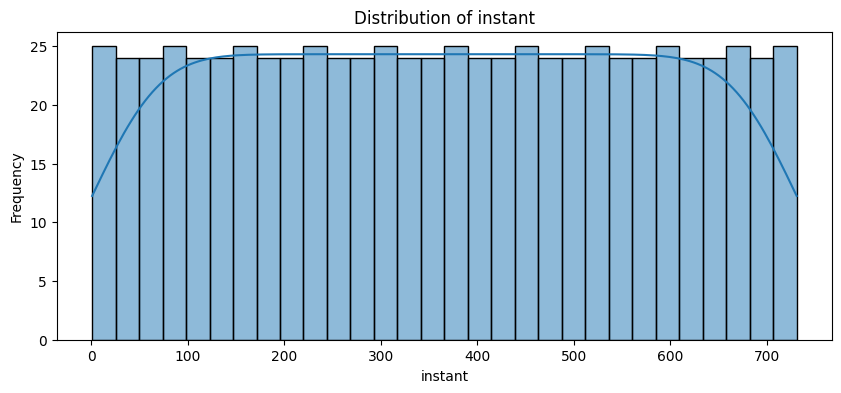

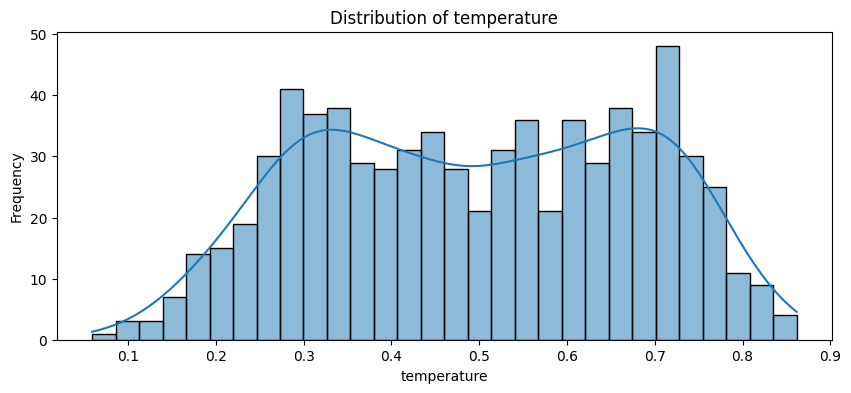

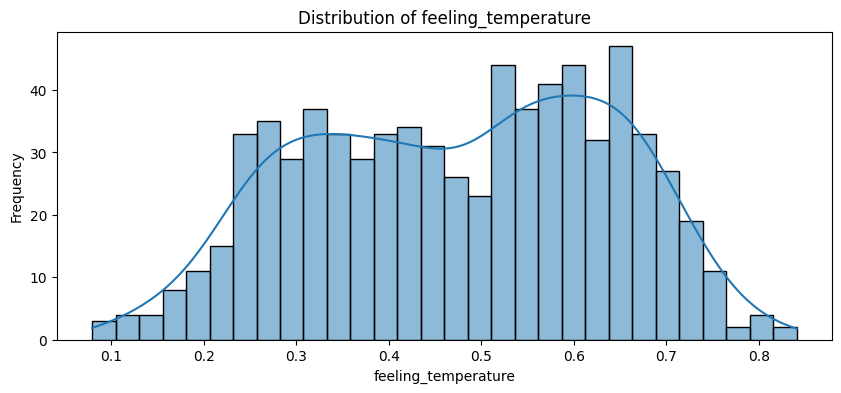

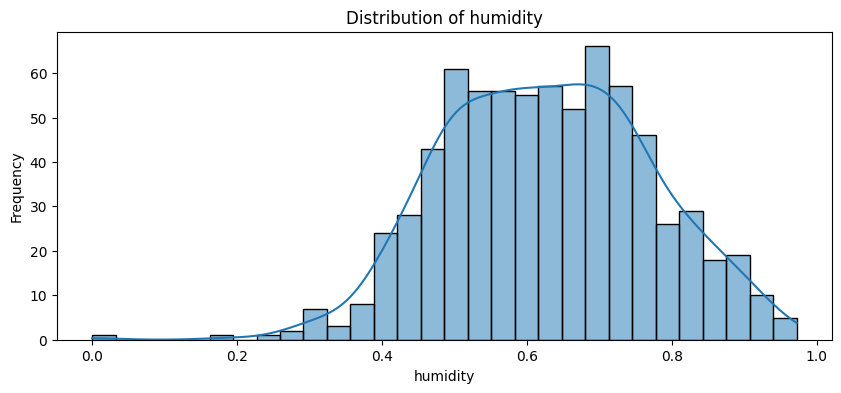

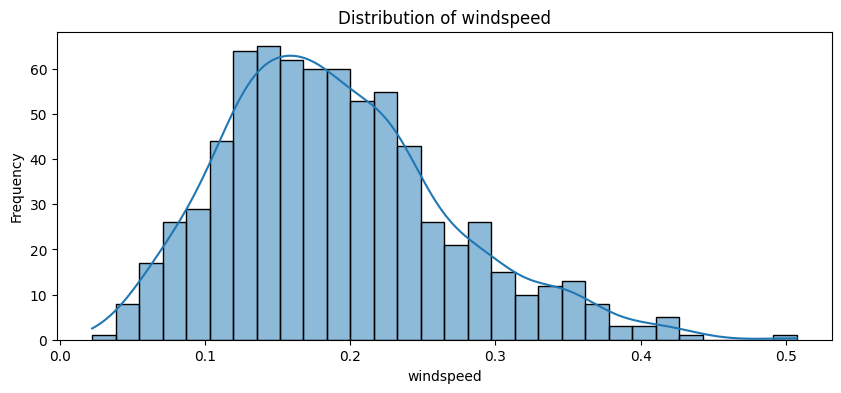

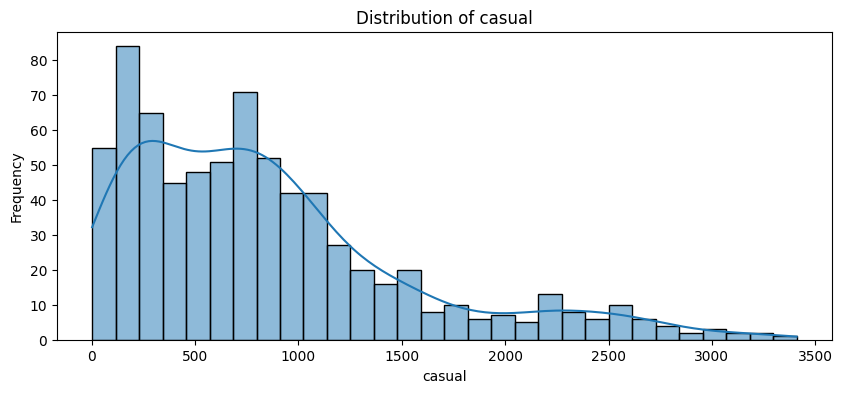

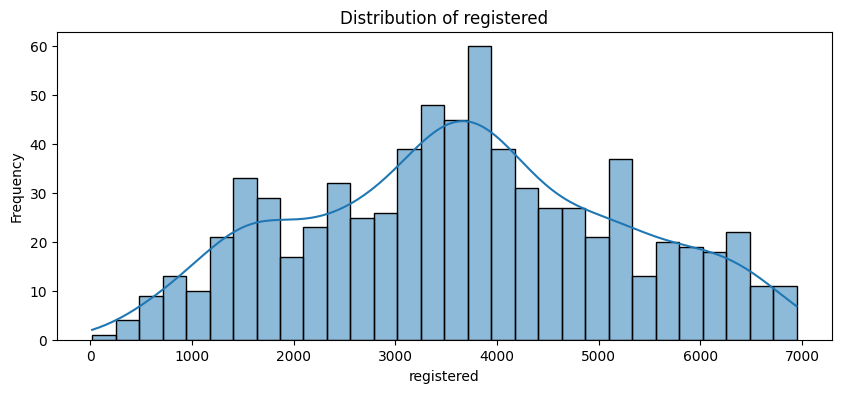

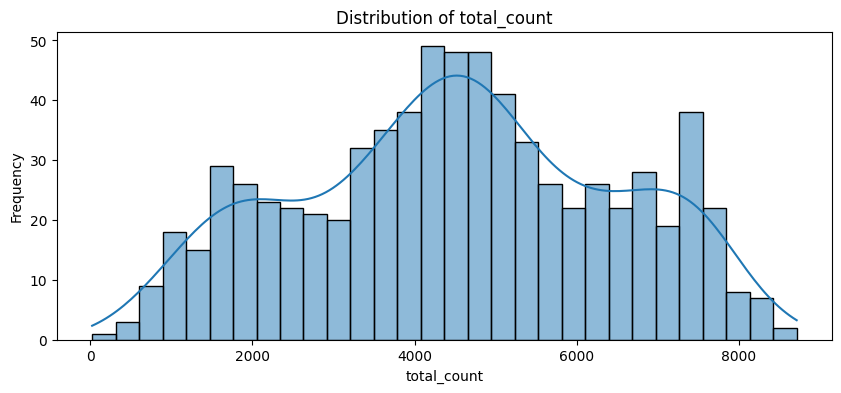

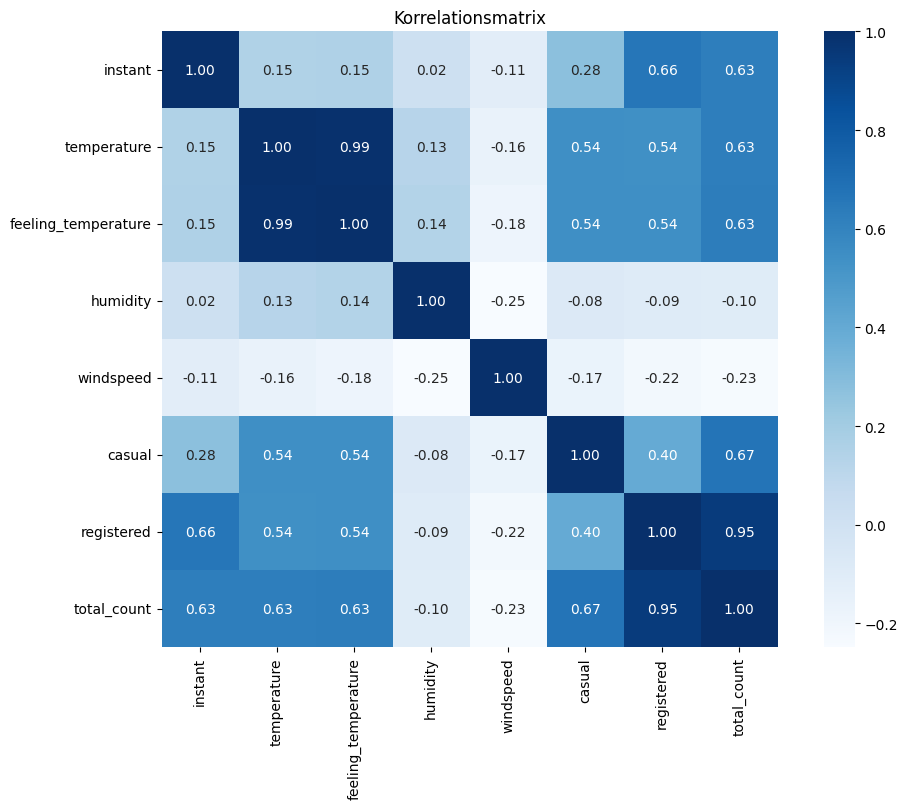

In [11]:
# TODO:
# 1. Analyze numerical variables
# 2. Visualize categorical variables
def analyze_numerical_features(df, numerical_features):
    """
    Analyzes numerical features in the DataFrame:
    - Displays descriptive statistics
    - Visualizes distributions and correlations
    """
    # Descriptive statistics
    display(Markdown("## Descriptive Statistics for Numerical Features"))
   

    # Visualize distributions of numerical features
    for feature in numerical_features:
        plt.figure(figsize=(10, 4))
        sns.histplot(df[feature], kde=True, bins=30)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.show()

# Analyze numerical features
analyze_numerical_features(day_bike, numerical_variables)

# Correlation matrix (heatmap) with blue colors
def plot_correlation_matrix(df, numerical_features):    
    """
    Plots a correlation matrix heatmap for numerical features in the DataFrame.
    
    Parameters:
    - df: DataFrame containing the data
    - numerical_features: List of numerical feature names
    """
    plt.figure(figsize=(12, 8))
    corr_matrix = df[numerical_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', square=True)
    plt.title('Korrelationsmatrix')
    plt.show()

# Plot the correlation matrix
plot_correlation_matrix(day_bike, numerical_variables)

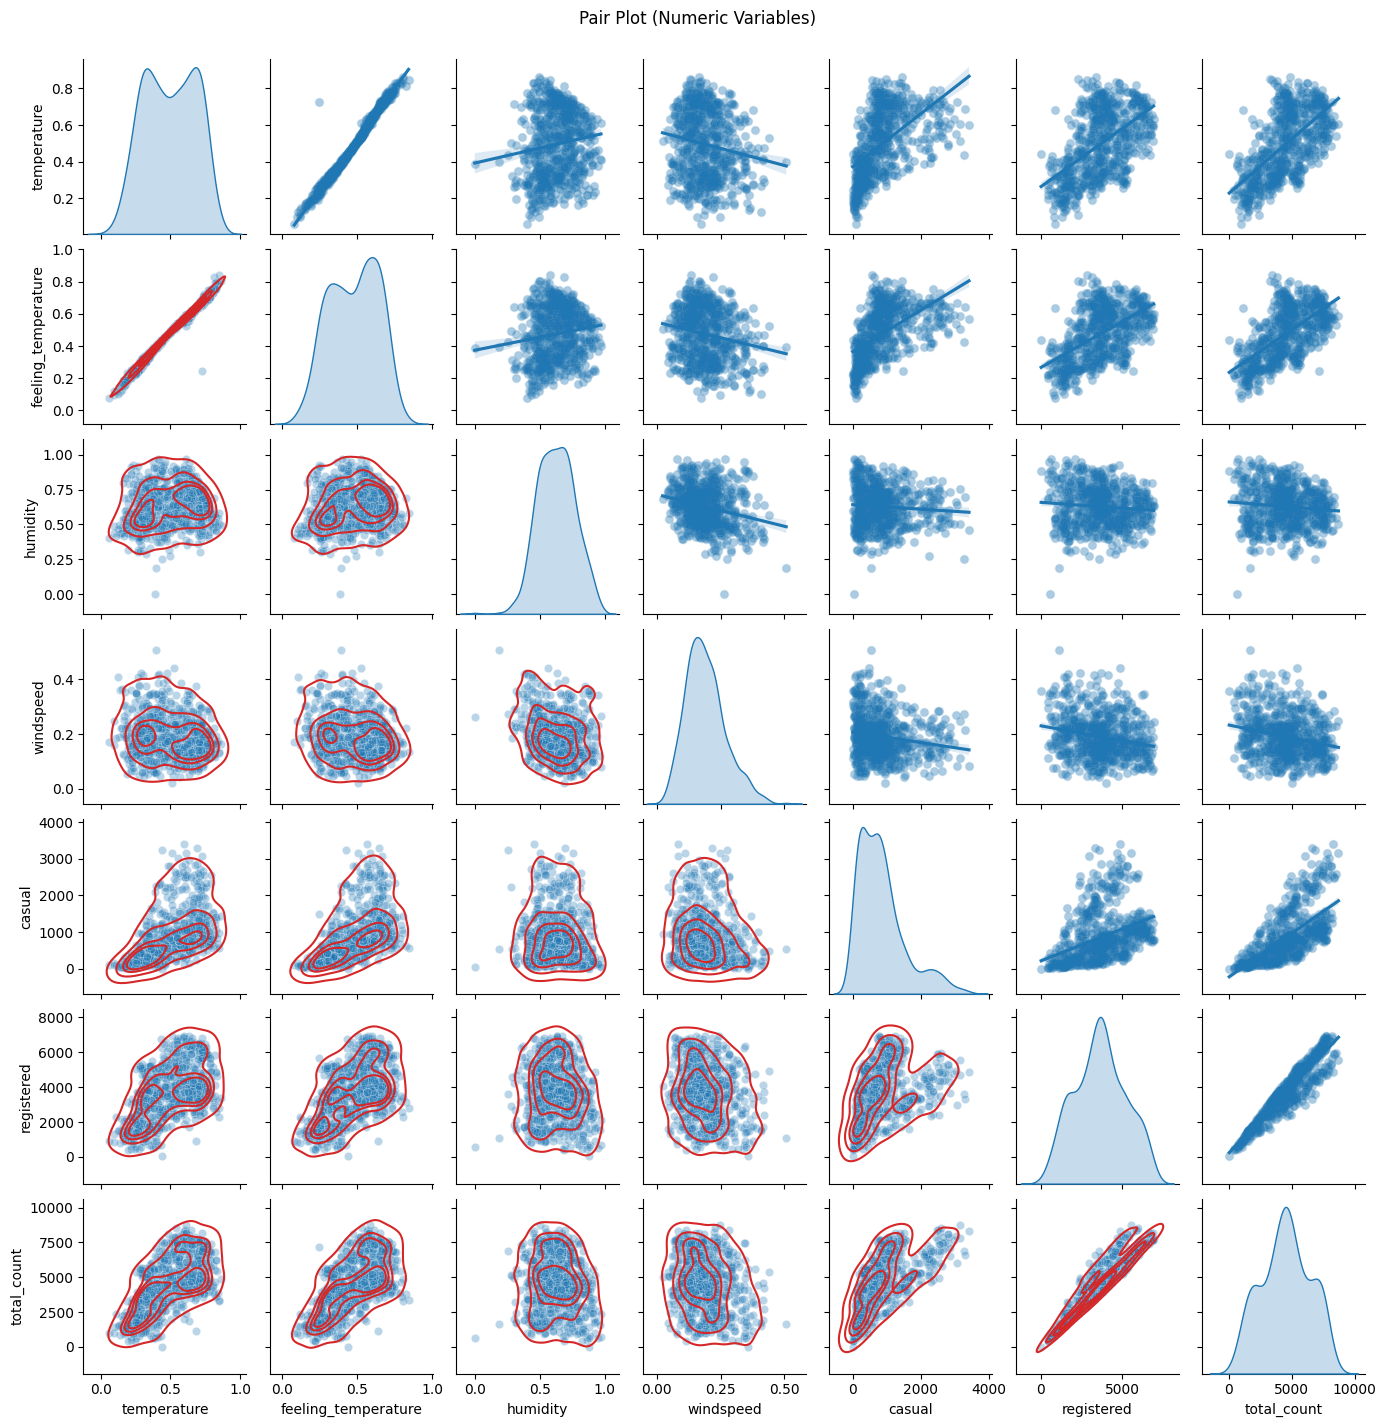

In [12]:
# Exclude 'instant' from numerical variables
num_vars = [col for col in numerical_variables if col != 'instant']
data = day_bike[num_vars]

# Optional: custom palette
sns_c = sns.color_palette()

g = sns.pairplot(
    data=data,
    diag_kind='kde',
    height=2,
    corner=False,
    plot_kws={'alpha': 0.3}
)

#  Lower triangular cells: KDE contours
g.map_lower(
    sns.kdeplot,
    levels=5,
    color=sns_c[3]
)

# Upper triangular cells: Regression lines
g.map_upper(
    sns.regplot,
    color=sns_c[0],
    scatter_kws={'alpha': 0.1}
)

# Adjust title
g.fig.suptitle('Pair Plot (Numeric Variables)', y=1.02)

plt.show()

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# List of numeric variables to be checked
features = ['temperature', 'humidity', 'windspeed', 'casual', 'feeling_temperature', 'total_count']

# DataFrame for VIF calculation (without NaNs)
X = day_bike[features].dropna()

# Add constant column (for VIF calculation)
X['constant'] = 1

# Calculate VIF values
vif_data = pd.DataFrame({
    'feature': features,
    'VIF': [
        variance_inflation_factor(X.values, i)
        for i in range(len(features))
    ]
})

print(vif_data)

               feature        VIF
0          temperature  63.104923
1             humidity   1.185795
2            windspeed   1.189058
3               casual   1.922367
4  feeling_temperature  63.984072
5          total_count   2.393392


### Regression result: total_count ~ temperature

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     473.5
Date:                Wed, 09 Jul 2025   Prob (F-statistic):           2.81e-81
Time:                        17:01:25   Log-Likelihood:                -6386.8
No. Observations:                 731   AIC:                         1.278e+04
Df Residuals:                     729   BIC:                         1.279e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1214.6421    161.164      7.537      

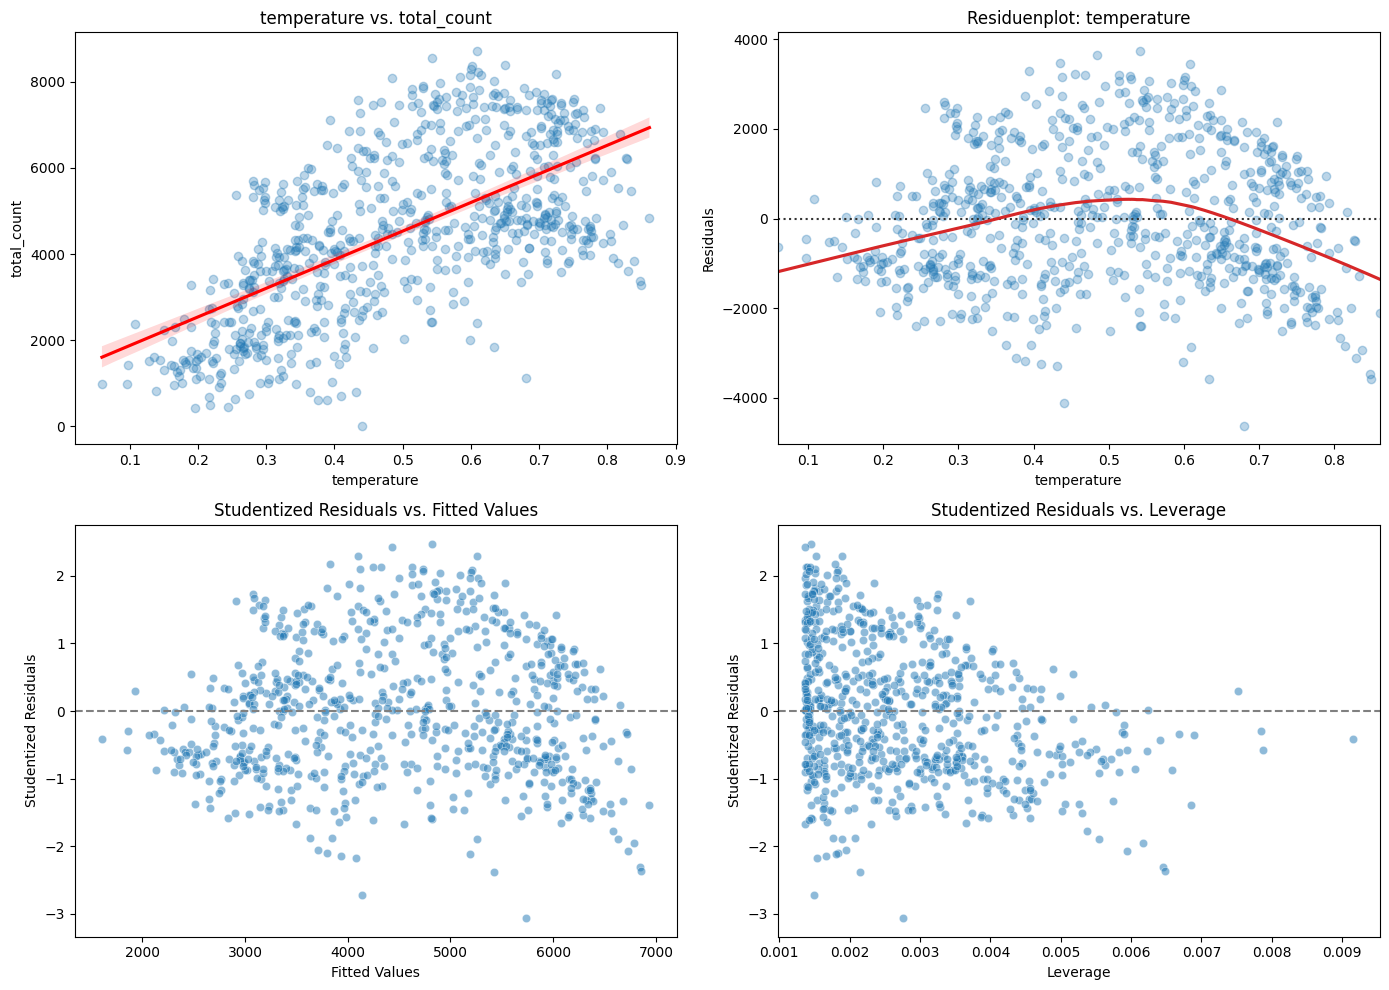

### Regression result: total_count ~ humidity

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.462
Date:                Wed, 09 Jul 2025   Prob (F-statistic):            0.00645
Time:                        17:01:32   Log-Likelihood:                -6566.0
No. Observations:                 731   AIC:                         1.314e+04
Df Residuals:                     729   BIC:                         1.315e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5363.9865    322.679     16.623      0.0

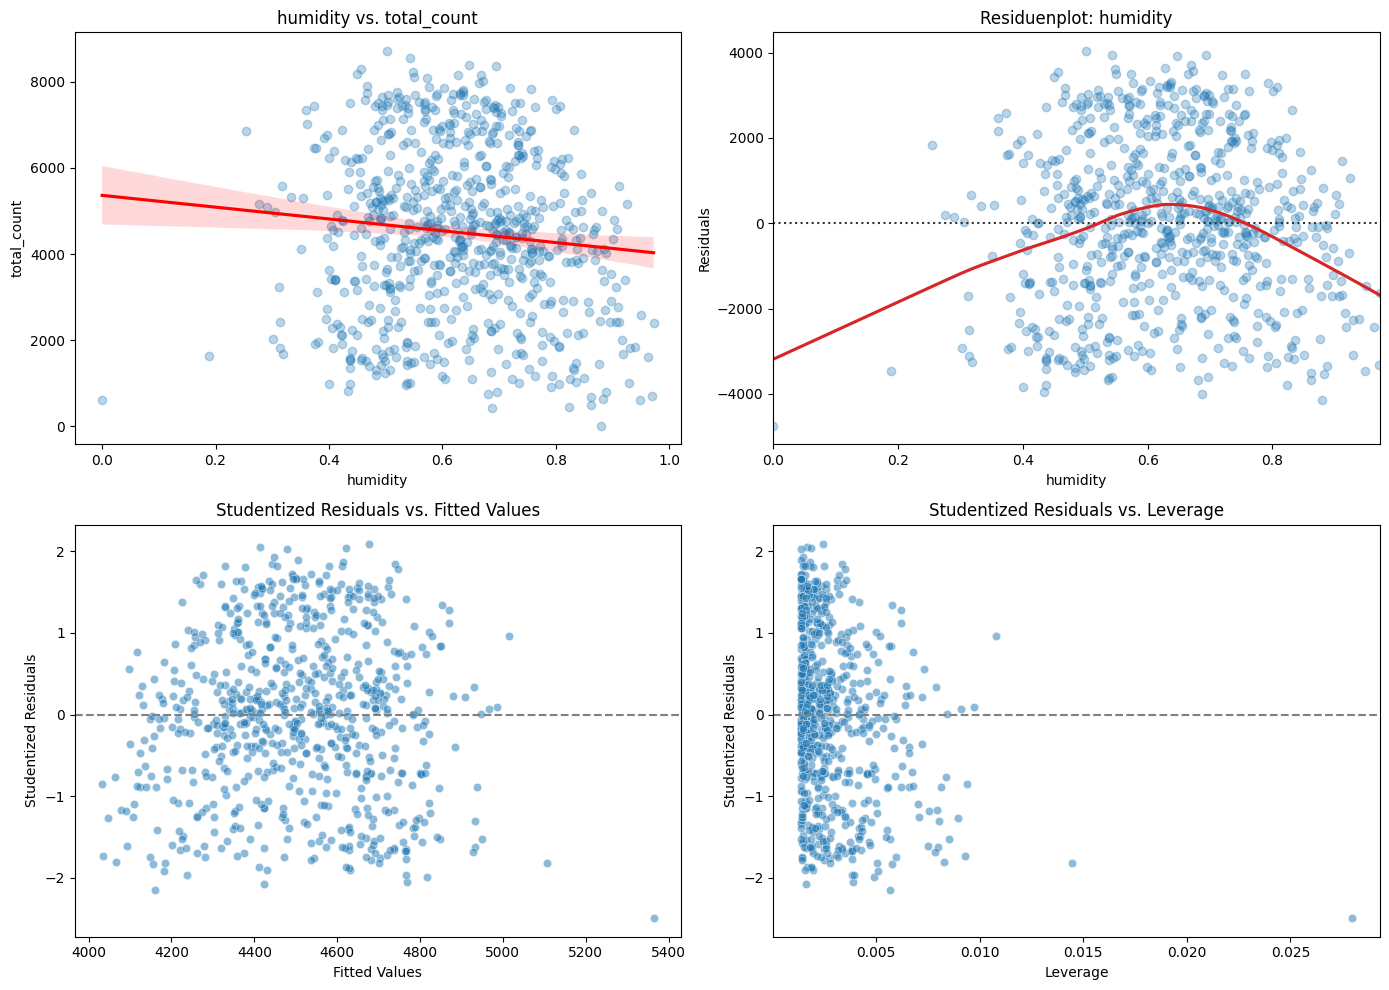

### Regression result: total_count ~ windspeed

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     42.44
Date:                Wed, 09 Jul 2025   Prob (F-statistic):           1.36e-10
Time:                        17:01:38   Log-Likelihood:                -6549.0
No. Observations:                 731   AIC:                         1.310e+04
Df Residuals:                     729   BIC:                         1.311e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5621.1529    185.062     30.374      0.0

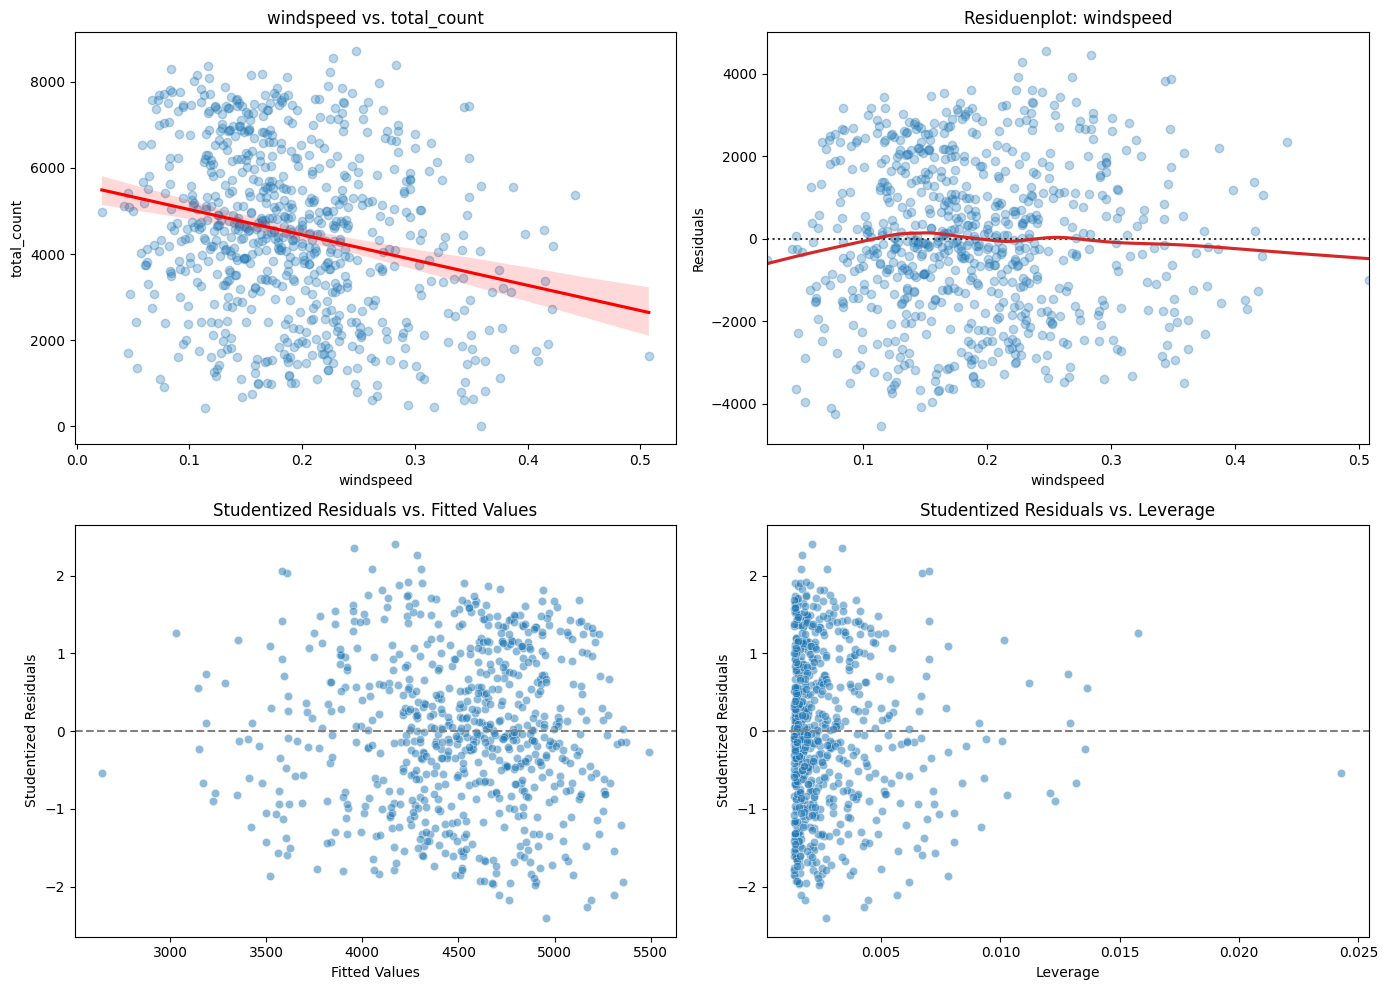

### Regression result: total_count ~ casual

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     602.9
Date:                Wed, 09 Jul 2025   Prob (F-statistic):           1.72e-97
Time:                        17:01:48   Log-Likelihood:                -6349.4
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     729   BIC:                         1.271e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2894.3185     84.340     34.317      0.0

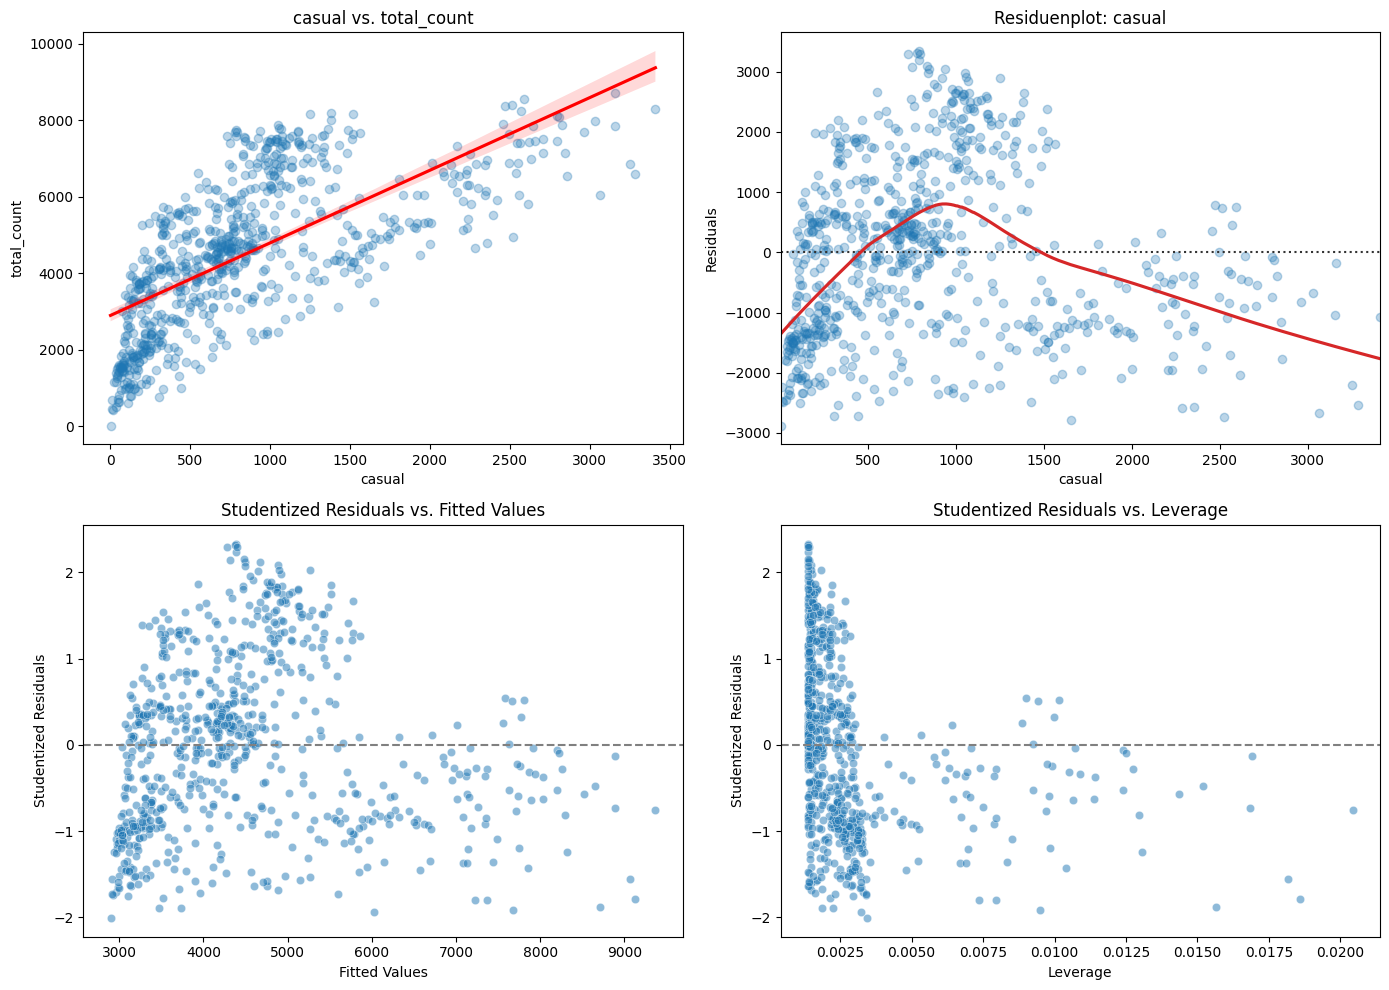

### Regression result: total_count ~ registered

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     6149.
Date:                Wed, 09 Jul 2025   Prob (F-statistic):               0.00
Time:                        17:01:56   Log-Likelihood:                -5749.4
No. Observations:                 731   AIC:                         1.150e+04
Df Residuals:                     729   BIC:                         1.151e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        212.1777     59.508      3.566      0.0

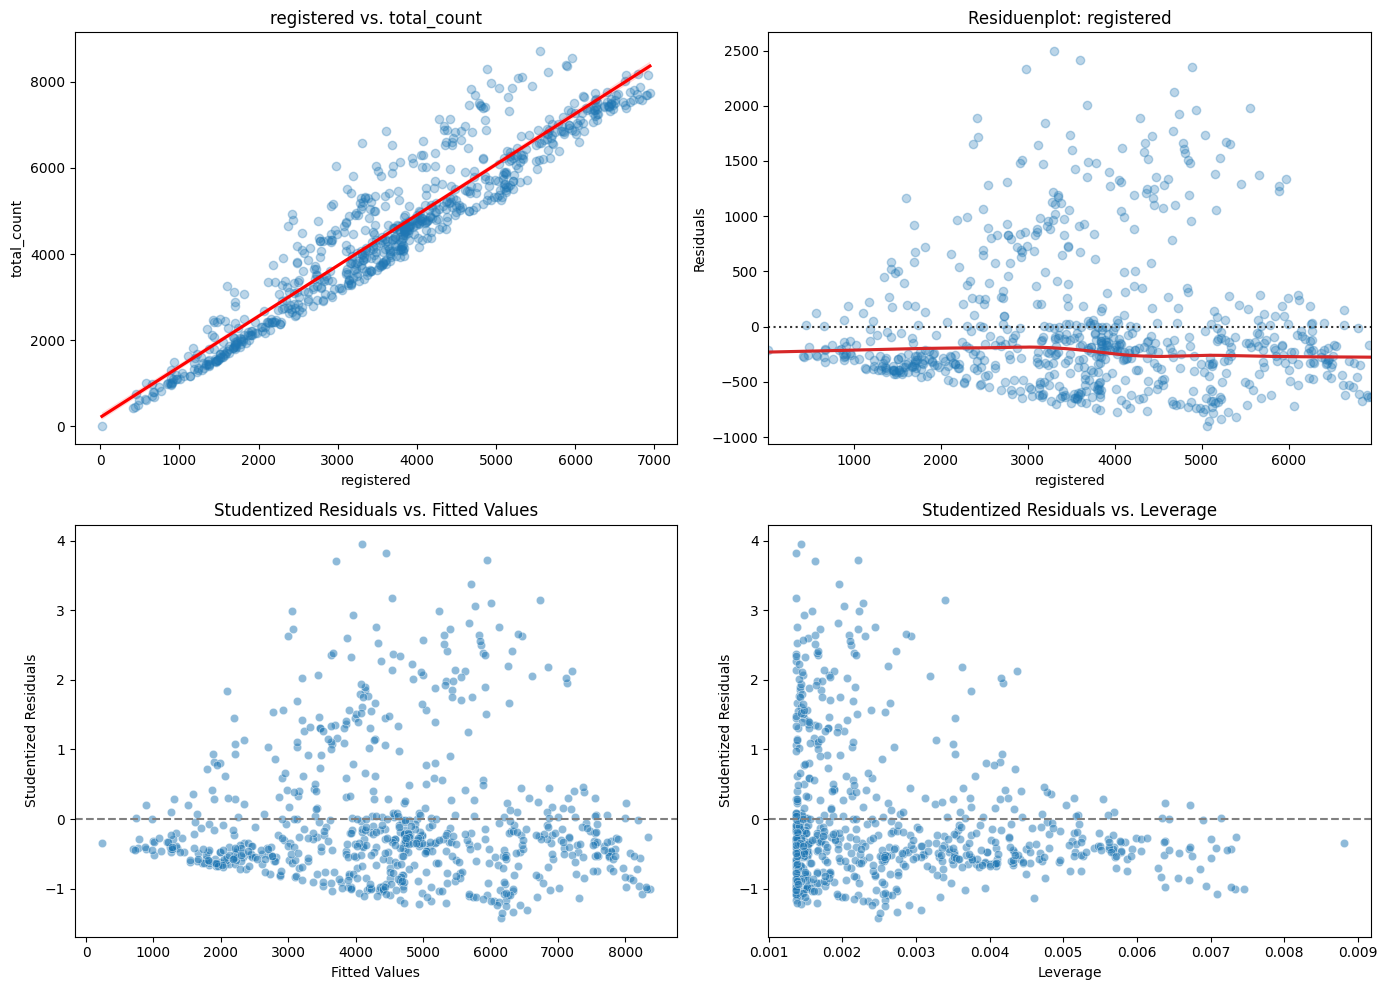

In [14]:
features = ['temperature', 'humidity', 'windspeed', 'casual', 'registered']
target = 'total_count'

# Dict to hold fitted models
models = {}
for feat in features:
    # 1. Regression with statsmodels
    X = sm.add_constant(day_bike[feat])
    model = sm.OLS(day_bike[target], X).fit()
    
    # Store model for later access
    models[feat] = model
    
    # Calculate diagnostic values
    influence = model.get_influence()
    stud_residuals = influence.resid_studentized_internal
    leverage = influence.hat_matrix_diag
    
    # 2. Model summary output
    display(Markdown(f"### Regression result: {target} ~ {feat}"))
    print(model.summary())
    
    # 3. Create a 2x2 grid for the plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Top row: Existing plots ---
    sns.regplot(x=feat, y=target, data=day_bike,
                ax=axes[0, 0], scatter_kws={'alpha': 0.3},
                line_kws={'color': 'red'})
    axes[0, 0].set_title(f'{feat} vs. {target}')
    
    sns.residplot(x=day_bike[feat], y=model.resid,
                  ax=axes[0, 1], lowess=True,
                  scatter_kws={'alpha': 0.3},
                  line_kws={'color': 'C3'})
    axes[0, 1].set_title(f'Residuenplot: {feat}')
    axes[0, 1].set_ylabel("Residuals")

    # --- Bottom row: New diagnostic plots ---
    # Studentized Residuals vs. Fitted Values
    sns.scatterplot(x=model.fittedvalues, y=stud_residuals, ax=axes[1, 0], alpha=0.5)
    axes[1, 0].axhline(0, ls='--', color='gray')
    axes[1, 0].set_title('Studentized Residuals vs. Fitted Values')
    axes[1, 0].set_xlabel('Fitted Values')
    axes[1, 0].set_ylabel('Studentized Residuals')

    # Studentized Residuals vs. Leverage
    sns.scatterplot(x=leverage, y=stud_residuals, ax=axes[1, 1], alpha=0.5)
    axes[1, 1].axhline(0, ls='--', color='gray')
    axes[1, 1].set_title('Studentized Residuals vs. Leverage')
    axes[1, 1].set_xlabel('Leverage')
    axes[1, 1].set_ylabel('Studentized Residuals')
    
    plt.tight_layout()
    plt.show()

## Quadratic Model: total_count ~ humidity + humidity²

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     30.86
Date:                Wed, 09 Jul 2025   Prob (F-statistic):           1.37e-13
Time:                        17:02:06   Log-Likelihood:                -6539.9
No. Observations:                 731   AIC:                         1.309e+04
Df Residuals:                     728   BIC:                         1.310e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1245.5145    954.185     -1.305      0.1

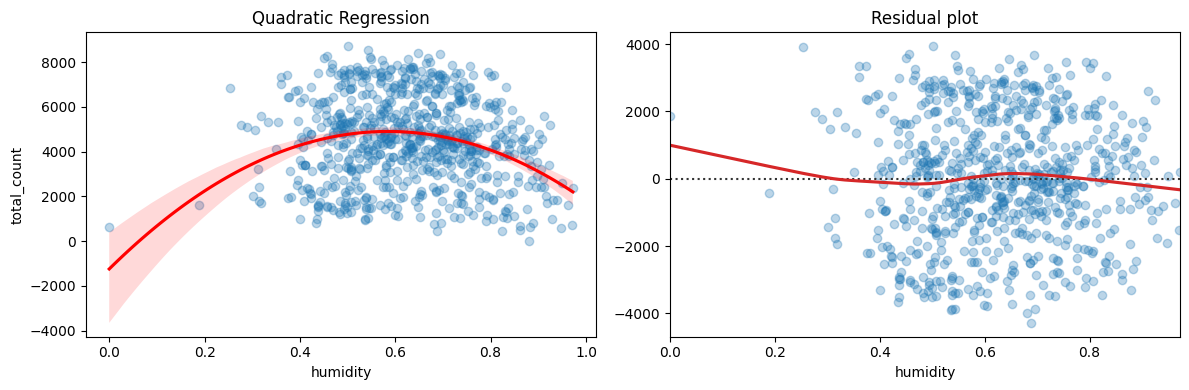

In [15]:
# New cell: Quadratic model for humidity

import statsmodels.api as sm
from IPython.display import display, Markdown

# Introduce quadratic term
day_bike['humidity2'] = day_bike['humidity']**2

X = sm.add_constant(day_bike[['humidity', 'humidity2']])
model_poly = sm.OLS(day_bike['total_count'], X).fit()

display(Markdown("## Quadratic Model: total_count ~ humidity + humidity²"))
print(model_poly.summary())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.regplot(x='humidity', y='total_count', data=day_bike, order=2,
            ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Quadratic Regression')
sns.residplot(x='humidity', y=model_poly.resid, data=day_bike,
              ax=axes[1], lowess=True, scatter_kws={'alpha':0.3},
              line_kws={'color':'C3'})
axes[1].set_title('Residual plot')
plt.tight_layout()
plt.show()

## Boxplots of Numerical Variables (Outlier Detection)

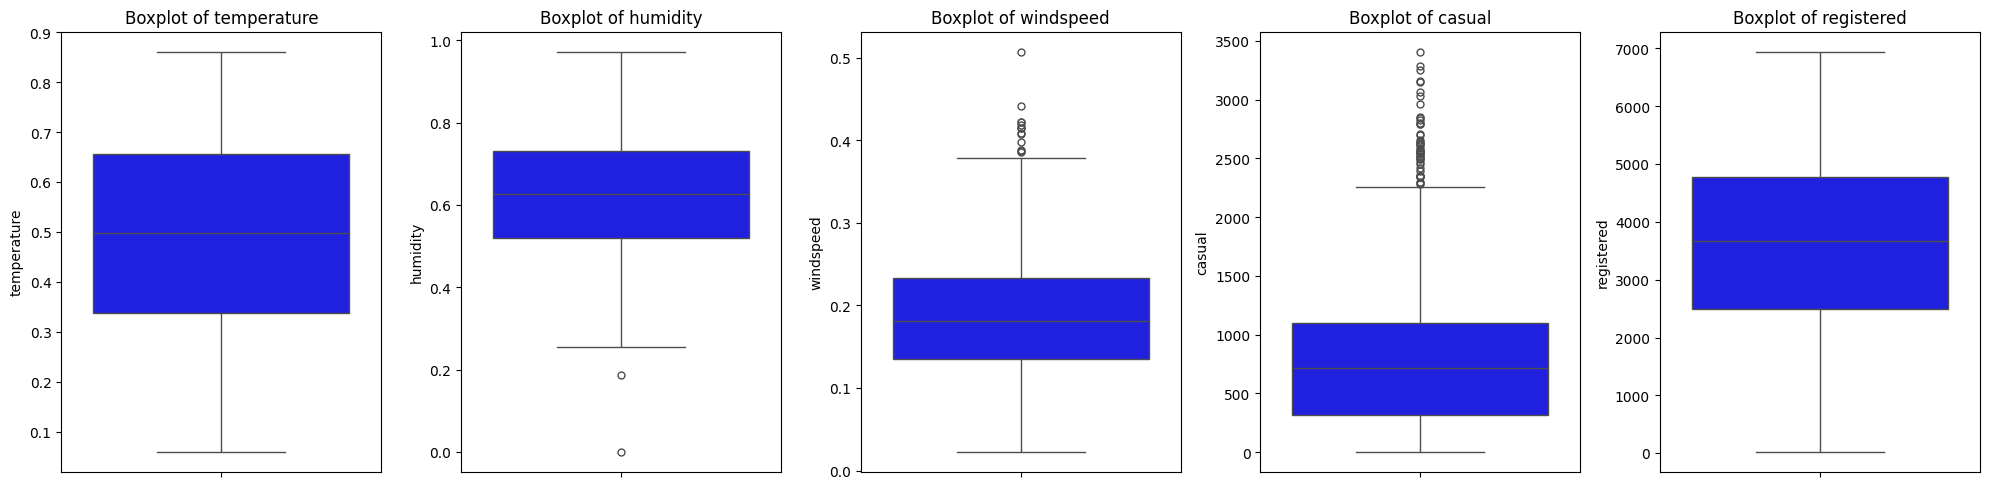

In [16]:
# Boxplots for Numerical Features to Identify Outliers



# List of numerical features to inspect
num_features = ['temperature', 'humidity', 'windspeed', 'casual', 'registered']

display(Markdown("## Boxplots of Numerical Variables (Outlier Detection)"))

# Create one row of subplots, one boxplot per feature
fig, axes = plt.subplots(nrows=1,
                         ncols=len(num_features),
                         figsize=(20, 5),
                         sharey=False)

# Loop over features and axes to draw boxplots
for ax, feature in zip(axes, num_features):
    sns.boxplot(y=day_bike[feature],
                ax=ax,
                color='blue',
                fliersize=5,
                linewidth=1)
    ax.set_title(f'Boxplot of {feature}')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

In [17]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# fig, axes = plt.subplots(nrows=4, ncols=2)
# fig.set_size_inches(20, 16)
# plt.subplots_adjust(hspace=0.3)

# # Boxplots for categorical and continuous features
# sns.boxplot(data=day_bike, y="total_count", ax=axes[0][0])
# sns.boxplot(data=day_bike, y="total_count", x="season", ax=axes[0][1])
# sns.boxplot(data=day_bike, y="total_count", x="year", ax=axes[1][0])
# sns.boxplot(data=day_bike, y="total_count", x="weathersit", ax=axes[1][1])
# sns.boxplot(data=day_bike, y="total_count", x="month", ax=axes[2][0])
# sns.boxplot(data=day_bike, y="total_count", x="weekday", ax=axes[2][1])
# sns.boxplot(data=day_bike, x="windspeed", ax=axes[3][0])
# sns.boxplot(data=day_bike, x="humidity", ax=axes[3][1])

# axes[0][0].set(ylabel='Count', title="Box Plot On Count")
# axes[0][1].set(ylabel='Count', title="Box Plot On Count Across Season")
# axes[0][1].set_xticklabels(['spring', 'summer', 'fall', 'winter'])

# axes[1][0].set(ylabel='Count', title="Box Plot On Count Across year")
# axes[1][0].set_xticklabels(['2011', '2012'])

# axes[1][1].set(ylabel='Count', title="Box Plot On Count Across weather")
# axes[1][1].set_xticklabels(['Clear', 'Mist', 'Snow'])

# axes[2][0].set(ylabel='Count', title="Box Plot On Count Across month")
# axes[2][1].set(ylabel='Count', title="Box Plot On Count Across weekday")
# axes[2][1].set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# axes[3][0].set(ylabel='windspeed', title="Box Plot On windspeed")
# axes[3][1].set(ylabel='humidity', title="Box Plot On humidity")

# plt.show()'

## Boxplots of Categorical Variables vs. total_count

C:\Users\chris\AppData\Local\Temp\ipykernel_10636\1250286354.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter']) # For 'season'
C:\Users\chris\AppData\Local\Temp\ipykernel_10636\1250286354.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(['2011', '2012']) # For 'year'
C:\Users\chris\AppData\Local\Temp\ipykernel_10636\1250286354.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[2].set_xticklabels(['Clear', 'Mist/Cloudy', 'Light Snow/Rain']) # For 'weathersit'
C:\Users\chris\AppData\Local\Temp\ipykernel_10636\1250286354.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[4].set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']) # For 'weekday'
C:\Users\chris\AppData\Local\Temp\ipykernel_10636\1250286354.py:32: UserWarning: FixedFormatter should only

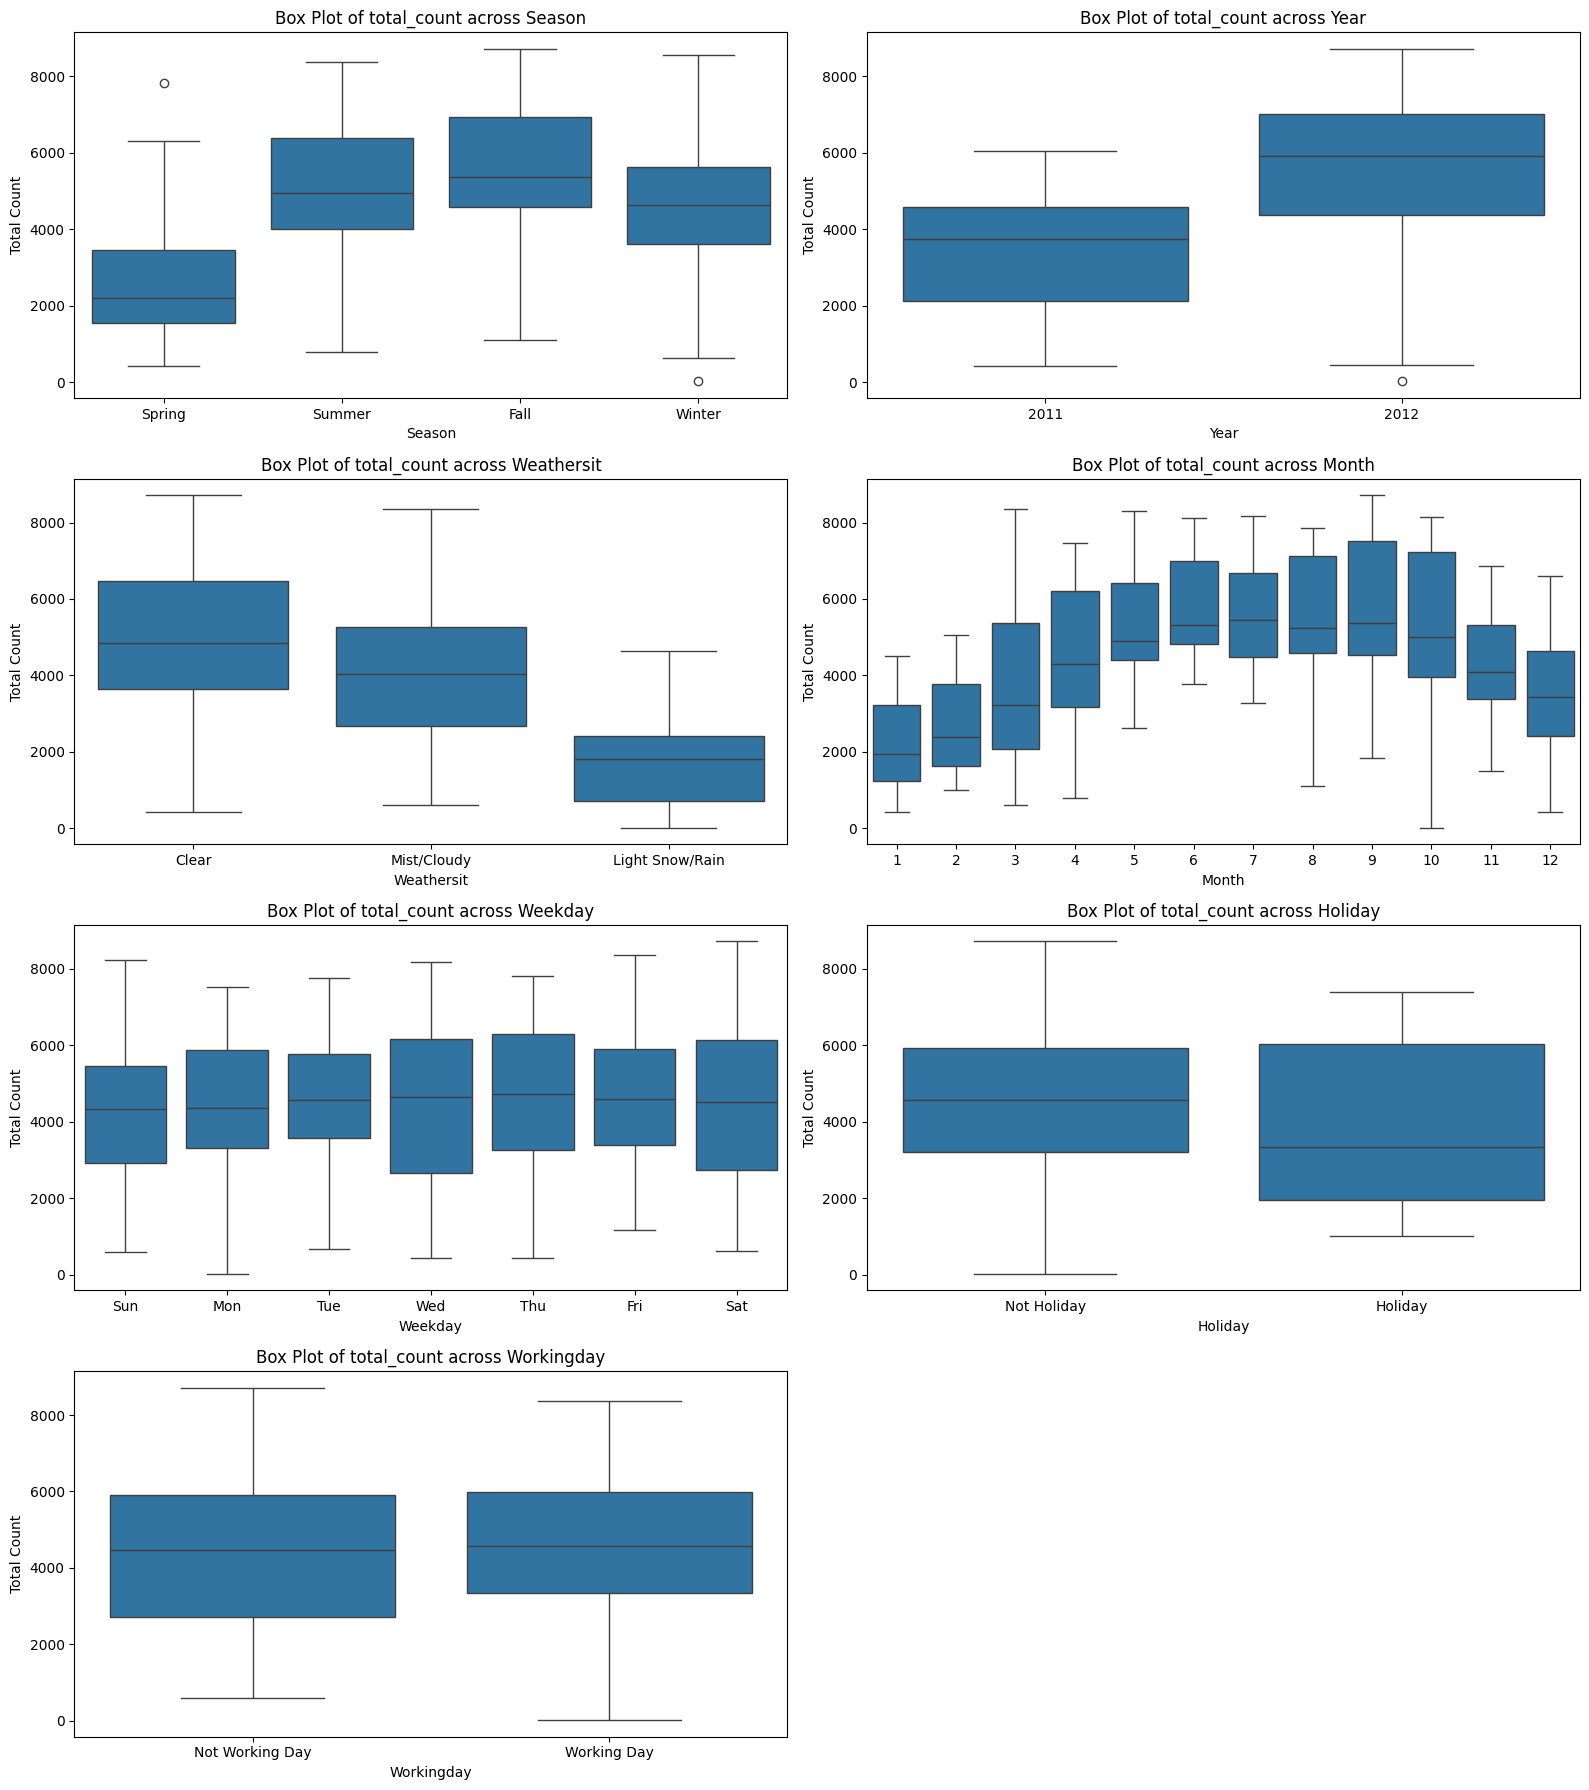

In [18]:
#Boxplots for Categorical Features vs. Total Count


# Define the categorical features to be plotted against the target variable
cat_features_for_plot = ['season', 'year', 'weathersit', 'month', 'weekday', 'holiday', 'workingday']
target = 'total_count'

# Create a figure and a set of subplots. A 4x2 grid.
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
# Flatten the axes array for easy iteration, which simplifies assigning plots to subplots
axes = axes.flatten()

display(Markdown(f"## Boxplots of Categorical Variables vs. {target}"))

# --- Plotting Loop ---
# Iterate through the list of categorical features and create a boxplot for each.
# 'enumerate' provides an index 'i' and the 'feature' name.
for i, feature in enumerate(cat_features_for_plot):
    ax = axes[i]
    # Create the boxplot using seaborn, assigning it to the current subplot axis
    sns.boxplot(data=day_bike, x=feature, y=target, ax=ax)
    # Set a descriptive title for each subplot
    ax.set_title(f'Box Plot of {target} across {feature.capitalize()}')
    ax.set_ylabel('Total Count')
    ax.set_xlabel(feature.capitalize())

# --- Customizing Labels for better readability ---
axes[0].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter']) # For 'season'
axes[1].set_xticklabels(['2011', '2012']) # For 'year'
axes[2].set_xticklabels(['Clear', 'Mist/Cloudy', 'Light Snow/Rain']) # For 'weathersit'
axes[4].set_xticklabels(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']) # For 'weekday'
axes[5].set_xticklabels(['Not Holiday', 'Holiday']) # For 'holiday'
axes[6].set_xticklabels(['Not Working Day', 'Working Day']) # For 'workingday'

# Hide the last subplot if it's unused (since we have 7 plots in a 4x2 grid)
axes[7].set_visible(False)

# Adjust the layout automatically to prevent titles and labels from overlapping
plt.tight_layout()
# Display the generated

## Analysis of Categorical Variables

### Feature: season

season
3    188
2    184
1    181
4    178
Name: count, dtype: int64

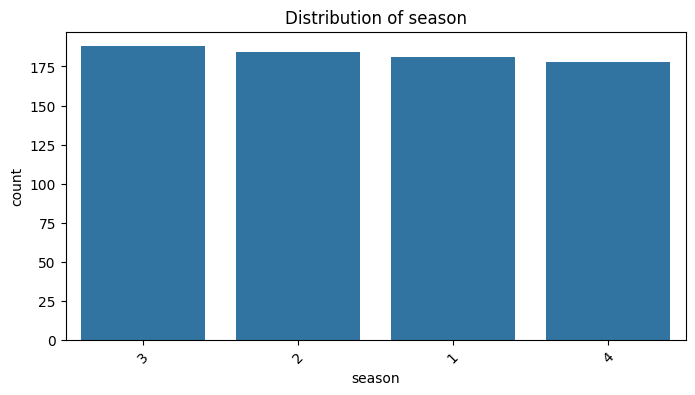

**Average total_count by season:**

season
3    5644.303191
2    4992.331522
4    4728.162921
1    2604.132597
Name: total_count, dtype: float64

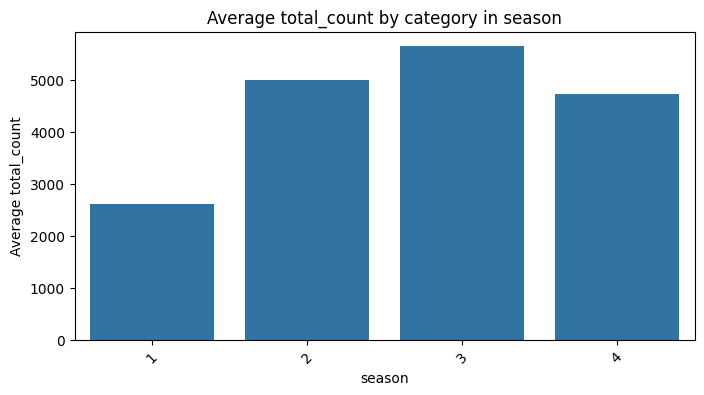

### Feature: year

year
1    366
0    365
Name: count, dtype: int64

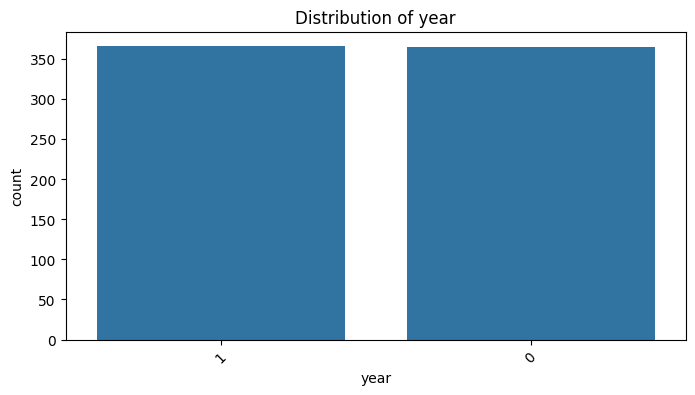

**Average total_count by year:**

year
1    5599.934426
0    3405.761644
Name: total_count, dtype: float64

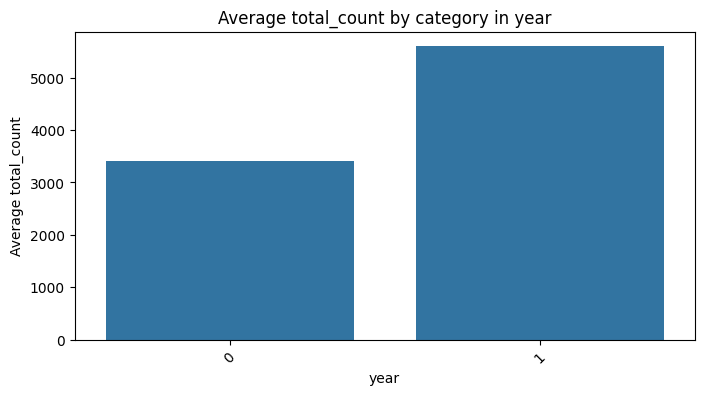

### Feature: month

month
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64

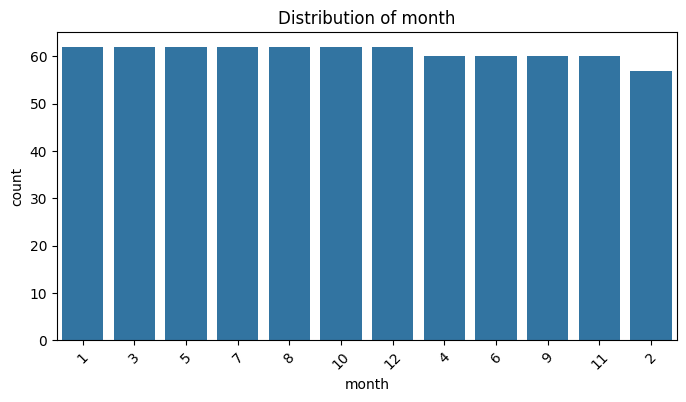

**Average total_count by month:**

month
6     5772.366667
9     5766.516667
8     5664.419355
7     5563.677419
5     5349.774194
10    5199.225806
4     4484.900000
11    4247.183333
3     3692.258065
12    3403.806452
2     2655.298246
1     2176.338710
Name: total_count, dtype: float64

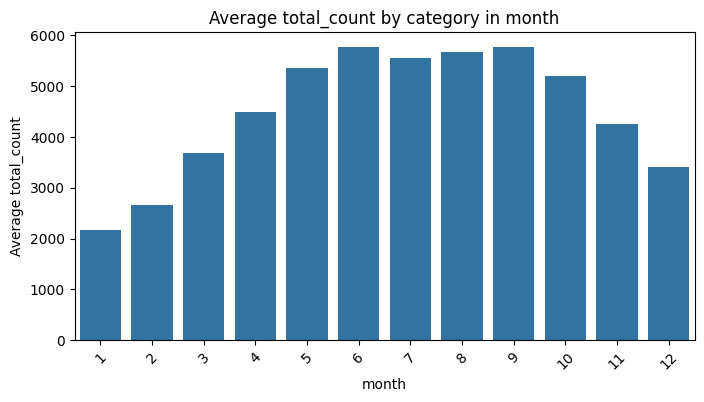

### Feature: holiday

holiday
0    710
1     21
Name: count, dtype: int64

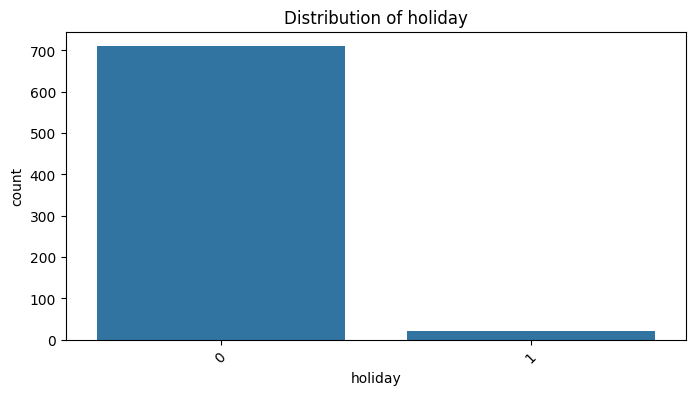

**Average total_count by holiday:**

holiday
0    4527.104225
1    3735.000000
Name: total_count, dtype: float64

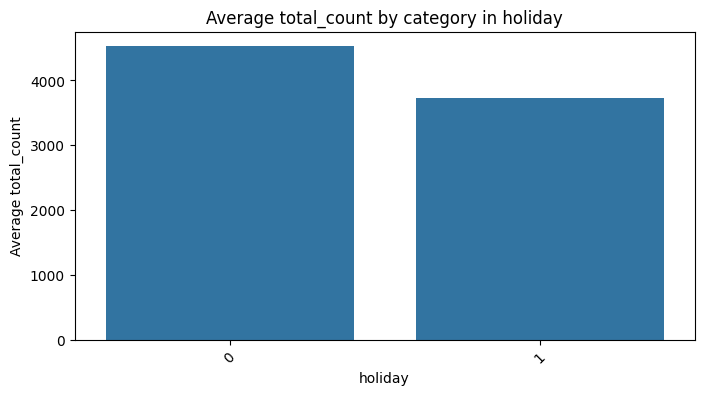

### Feature: weekday

weekday
6    105
0    105
1    105
2    104
3    104
4    104
5    104
Name: count, dtype: int64

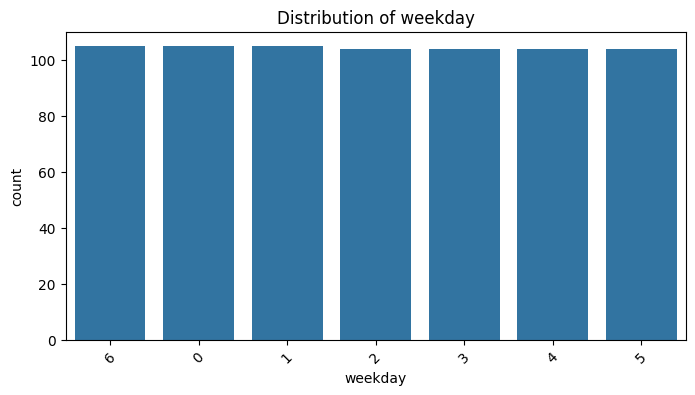

**Average total_count by weekday:**

weekday
5    4690.288462
4    4667.259615
6    4550.542857
3    4548.538462
2    4510.663462
1    4338.123810
0    4228.828571
Name: total_count, dtype: float64

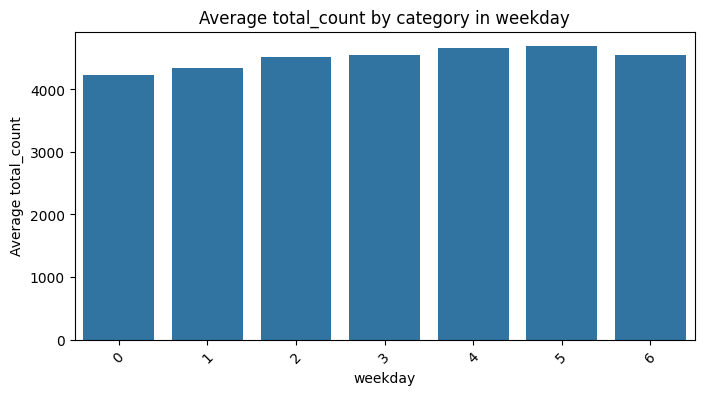

### Feature: workingday

workingday
1    500
0    231
Name: count, dtype: int64

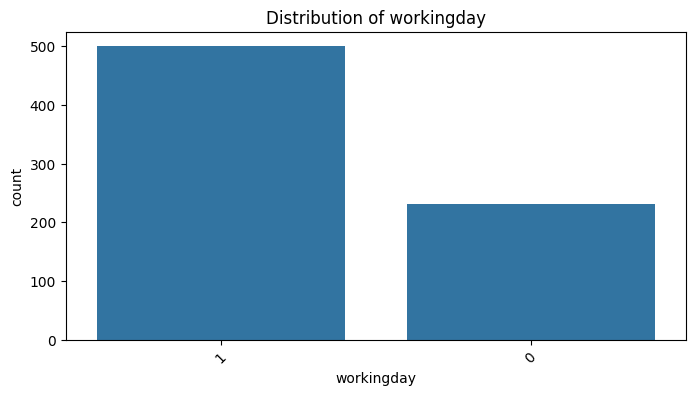

**Average total_count by workingday:**

workingday
1    4584.820000
0    4330.168831
Name: total_count, dtype: float64

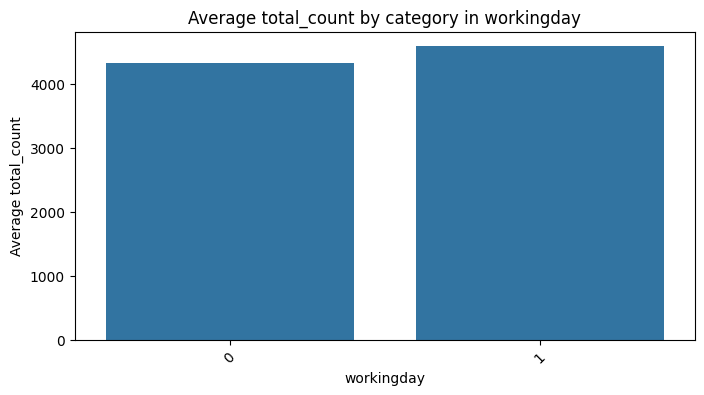

### Feature: weathersit

weathersit
1    463
2    247
3     21
Name: count, dtype: int64

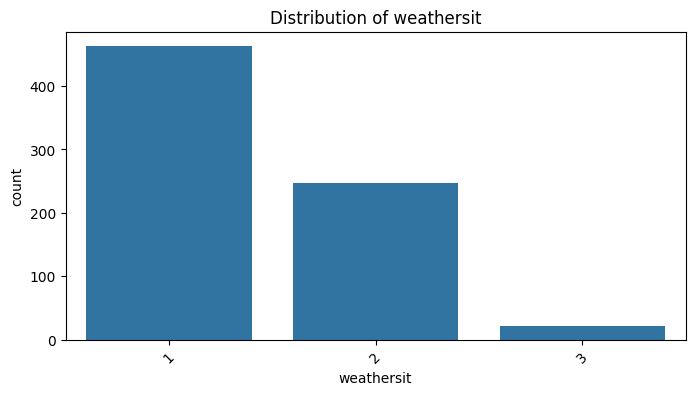

**Average total_count by weathersit:**

weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: total_count, dtype: float64

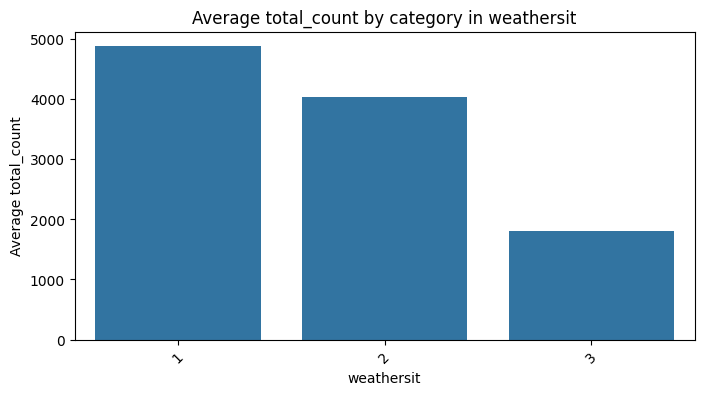

In [ ]:
# # New Cell: Analysis of Categorical Variables
# from IPython.display import display, Markdown

# def analyze_categorical_features(df, cat_features, target=None):
#     """
#     Analyze categorical variables:
#     - Display frequency distributions
#     - Plot countplots for each feature
#     - (Optional) Aggregate by feature and calculates the mean of the target variable
#     """
#     display(Markdown("## Analysis of Categorical Variables"))
    
#     for feature in cat_features:
#         display(Markdown(f"### Feature: {feature}"))
        
#         # Display the frequency distribution
#         counts = df[feature].value_counts()
#         display(counts)
        
#         # Create a countplot
#         plt.figure(figsize=(8, 4))
#         sns.countplot(x=feature, data=df, order=counts.index)
#         plt.title(f'Distribution of {feature}')
#         plt.xticks(rotation=45)
#         plt.show()
        
#         # Optional analysis: aggregate target variable if provided
#         if target is not None and target in df.columns:
#             group_stats = df.groupby(feature)[target].mean().sort_values(ascending=False)
#             display(Markdown(f"**Average {target} by {feature}:**"))
#             display(group_stats)
#             plt.figure(figsize=(8, 4))
#             sns.barplot(x=group_stats.index, y=group_stats.values)
#             plt.title(f'Average {target} by category in {feature}')
#             plt.xticks(rotation=45)
#             plt.ylabel(f'Average {target}')
#             plt.show()

# # Calling the function with our categorical variables
# analyze_categorical_features(day_bike, categorical_variables, target="total_count")

In [20]:

def detect_outliers_and_leverage(df, feature_cols, target_col, outlier_factor=3.0, leverage_factor=1.0):
    """
    Fit an OLS regression model on the specified features and target,
    compute influence measures and flags:
      - is_potential_outlier: |studentized residual| > outlier_factor
      - is_high_leverage: hat value > (p+1)/n
    """
    # Prepare design matrix
    X = df[feature_cols].copy()
    X = sm.add_constant(X)
    y = df[target_col]

    # Fit OLS model
    model = sm.OLS(y, X).fit()

    # Influence measures
    infl = model.get_influence()
    hat_vals = infl.hat_matrix_diag
    stud_resid = infl.resid_studentized_internal

    # Thresholds
    n, p = X.shape[0], X.shape[1] - 1
    print(n, p )
    leverage_thresh = ((p + 1) / n) * leverage_factor
    print(leverage_thresh)

    # Flags
    is_outlier = np.abs(stud_resid) > outlier_factor
    is_high_lev = hat_vals > leverage_thresh

    # Build results
    results = pd.DataFrame({
        'residuals': model.resid,
        'standardized_residuals': stud_resid,
        'leverage': hat_vals,
        'is_potential_outlier': is_outlier,
        'is_high_leverage': is_high_lev
    }, index=df.index)

    return results, model


In [21]:
# Applying the Outlier/Leverage Detection Function


# 1. Define the feature sets and the target variable
numerical_features = ['temperature', 'humidity', 'windspeed', 'casual', 'registered']
# Note: 'month' and 'weekday' can be treated as categorical
categorical_features = ['season', 'year', 'month', 'weekday', 'weathersit', 'holiday', 'workingday']
target_col = 'total_count'

# 2. Create one-hot encoded features from the categorical variables
# Using drop_first=True to avoid perfect multicollinearity
day_bike_dummies = pd.get_dummies(day_bike[categorical_features], 
                                  columns=categorical_features, 
                                  drop_first=True, 
                                  dtype=float)

# 3. Combine the numerical features and the new dummy variables
X_full = pd.concat([day_bike[numerical_features], day_bike_dummies], axis=1)

# The function needs a single DataFrame with both features and target
df_for_model = pd.concat([X_full, day_bike[target_col]], axis=1)

# 4. Get the final list of all predictor columns
all_feature_cols = X_full.columns.tolist()

# 5. Call the detection function with the prepared data
# We can adjust the outlier_fraction, e.g., to 5% for the full model
influence_df, full_model = detect_outliers_and_leverage(
    df=df_for_model,
    feature_cols=all_feature_cols,
    target_col=target_col,
    leverage_factor=2.0,  # Adjust leverage factor 
)

# 6. Display the summary of the fitted regression model
display(Markdown("## Full Regression Model Summary"))
print(full_model.summary())

# 7. Display the points that were flagged as either potential outliers or high-leverage
display(Markdown("## Identified Potential Outliers and/or High-Leverage Points"))
problematic_points = influence_df[
    (influence_df['is_potential_outlier']) | (influence_df['is_high_leverage'])
]
display(problematic_points)

print(f"\nTotal number of problematic points found: {len(problematic_points)}")

731 30
0.08481532147742818


## Full Regression Model Summary

                            OLS Regression Results                            
Dep. Variable:            total_count   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.185e+30
Date:                Wed, 09 Jul 2025   Prob (F-statistic):               0.00
Time:                        17:02:41   Log-Likelihood:                 18282.
No. Observations:                 731   AIC:                        -3.650e+04
Df Residuals:                     701   BIC:                        -3.637e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -7.603e-13   1.08e-12     -0.706   

## Identified Potential Outliers and/or High-Leverage Points

,residuals,standardized_residuals,leverage,is_potential_outlier,is_high_leverage
68,9.094947e-13,0.293871,0.170099,False,True
89,-2.728484e-12,-0.847825,0.102635,False,True
104,9.094947e-13,0.280683,0.090280,False,True
184,4.547474e-12,1.418897,0.110026,False,True
301,-2.273737e-13,-0.070030,0.086621,False,True
314,4.547474e-12,1.401002,0.087145,False,True
339,9.094947e-13,0.280092,0.086436,False,True
340,-1.591616e-12,-0.490037,0.085977,False,True
359,-6.821210e-13,-0.210004,0.085871,False,True
406,0.000000e+00,0.000000,0.086547,False,True



Total number of problematic points found: 18


# 3. Modeling and Optimization

Modeling and Optimization Strategy：

In this section, we define the machine learning task and modeling approach used in the project.

The target variable in this dataset is `total_count`, which represents the total number of bike rentals per day. Since `total_count` is a continuous numerical value rather than a category or label, the task is defined as a **regression problem**.

We explore and compare four different regression models, each building on or differing from the previous by applying advanced machine learning concepts:

- **Linear Regression**: A baseline model assuming a linear relationship between features and target. Simple and interpretable but limited in capturing complex patterns. Later, polynomial features will be introduced to this model to better capture nonlinear relationships.

- **Ridge Regression**: Extends linear regression with L2 regularization (penalty on the squared magnitude of coefficients) to prevent overfitting, especially when features are many or correlated. Controls complexity better than Linear Regression.

- **Lasso Regression**: Similar to Ridge but uses L1 regularization (penalty on the absolute value of coefficients). Besides reducing overfitting, it can set some coefficients to zero, performing automatic feature selection which Ridge cannot.

- **Random Forest Regression**: An ensemble of decision trees that combines multiple trees to improve accuracy and generalization. It models complex interactions and nonlinearities better than a single tree and reduces overfitting by averaging.

To further enhance model performance and ensure robust generalization, we apply machine learning techniques such as hyperparameter tuning using GridSearchCV with cross-validation:

- **Ridge and Lasso Regression**: The key hyperparameter tuned is `alpha`, the regularization strength. Adjusting `alpha` helps find the optimal trade-off between underfitting and overfitting by controlling the amount of shrinkage applied to the model coefficients.

- **Random Forest Regression**: We tune hyperparameters such as `max_depth` (maximum tree depth), `min_samples_leaf` (minimum samples per leaf), and others. These parameters help balance bias and variance by controlling the complexity of the tree structure.

These optimization steps help prevent overfitting and ensure the models generalize well on unseen data. All models are trained on the training set and evaluated on the test set to compare their predictive performance.

## 3.1 Linear Regression

Step 0: Null Model MSE = 3747654.56
Step 1: Added 'casual', CV MSE: 2654864.10
Step 2: Added 'workingday_1', CV MSE: 1640334.63
Step 3: Added 'year_1', CV MSE: 1041227.67
Step 4: Added 'season_4', CV MSE: 847649.00
Step 5: Added 'temperature', CV MSE: 566539.52
Step 6: Added 'weathersit_3', CV MSE: 511552.58
Step 7: Added 'weathersit_2', CV MSE: 487275.88
Step 8: Added 'month_7', CV MSE: 476919.79
Step 9: Added 'windspeed', CV MSE: 471361.29
Step 10: Added 'weekday_1', CV MSE: 467944.85
Step 11: Added 'weekday_6', CV MSE: 465570.69
Step 12: Added 'month_4', CV MSE: 463928.58
Step 13: Added 'season_3', CV MSE: 462673.41
Step 14: Added 'season_2', CV MSE: 432566.45
Step 15: Added 'weekday_4', CV MSE: 431578.75
Step 16: Added 'month_8', CV MSE: 431388.80
Step 17: Added 'month_2', CV MSE: 431177.76
Step 18: Added 'holiday_1', CV MSE: 431750.22
Step 19: Added 'month_11', CV MSE: 432225.13
Step 20: Added 'weekday_5', CV MSE: 432390.18
Step 21: Added 'month_10', CV MSE: 432799.94
Step 22: Add

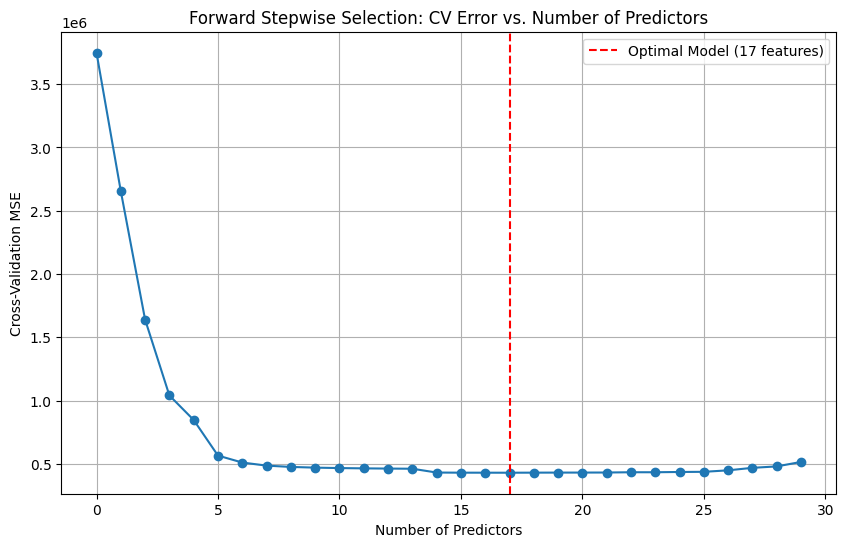

In [22]:
# --- 1. Data Preparation (linear) ---

# Drop columns that are not needed or would cause data leakage
# 'date' is redundant, 'casual' and 'registered' sum up to the target 'total_count'
# 'feeling_temperature' is highly correlated with 'temperature'
df_model_linear = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'])
# Define features (X) and target (y)
X_linear = df_model_linear.drop('total_count', axis=1)
y_linear = df_model_linear['total_count']

# Identify numerical and categorical features for the preprocessor
categorical_features_linear = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_linear = [col for col in X_linear.columns if col not in categorical_features_linear]                                     

# Create a preprocessor for scaling and one-hot encoding
# Using drop='first' to avoid multicollinearity (dummy variable trap)
# Using sparse_output=False to ensure dense arrays for subsequent pipeline steps
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_linear),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_linear)
    ],
    remainder='passthrough'
)

# Get the full list of feature names after preprocessing
preprocessor_linear.fit(X_linear)
ohe_names_linear = preprocessor_linear.named_transformers_['cat'].get_feature_names_out(categorical_features_linear)
all_names_linear = numerical_features_linear + ohe_names_linear.tolist()

def forward_stepwise_selection(X, y, preprocessor, all_feature_names, cv_folds=5):
    """
    Perform forward stepwise selection on the entire dataset using cross-validation.

    Args:
        X (pd.DataFrame): The full feature dataset.
        y (pd.Series): The full target dataset.
        preprocessor (ColumnTransformer): The preprocessor for scaling and encoding.
        all_feature_names (list): A list of all feature names after preprocessing.
        cv_folds (int): The number of folds for cross-validation.

    Return:
        tuple: A tuple containing:
            - pd.DataFrame: A history of MSE and features at each step.
            - list: The list of the best features found.
    """
    remaining_features = all_feature_names.copy()
    selected_features = []
    history_mse = []
    history_features = []

    # Step 0: Calculate Null Model MSE (predicting the mean)
    null_mse = mean_squared_error(y, np.full_like(y, y.mean()))
    history_mse.append(null_mse)
    history_features.append([])
    print(f"Step 0: Null Model MSE = {null_mse:.2f}")

    # Iterate from 1 to the total number of features
    for i in range(len(all_feature_names)):
        best_score_for_step = -np.inf
        best_feature_for_step = None
        
        for feature in remaining_features:
            current_features = selected_features + [feature]
            feature_indices = [all_feature_names.index(f) for f in current_features]
            
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('selector', ColumnTransformer([('selector', 'passthrough', feature_indices)], remainder='drop')),
                ('regressor', LinearRegression())
            ])
            
            # Perform cross-validation on the full dataset
            scores = cross_val_score(pipeline, X, y, cv=cv_folds, scoring='neg_mean_squared_error')
            current_score = scores.mean()
            
            if current_score > best_score_for_step:
                best_score_for_step = current_score
                best_feature_for_step = feature
        
        if best_feature_for_step:
            selected_features.append(best_feature_for_step)
            remaining_features.remove(best_feature_for_step)
            history_mse.append(-best_score_for_step)
            history_features.append(selected_features.copy())
            print(f"Step {i+1}: Added '{best_feature_for_step}', CV MSE: {-best_score_for_step:.2f}")
        else:
            print("No further improvement. Stopping selection.")
            break

    history_df = pd.DataFrame({
        'num_features': range(len(history_mse)),
        'cv_mse': history_mse,
        'features': history_features
    })

    best_model_idx = history_df['cv_mse'].idxmin()
    best_features = history_df.loc[best_model_idx, 'features']
    
    print(f"\nOptimal number of features found: {len(best_features)}")
    print(f"Lowest CV MSE: {history_df.loc[best_model_idx, 'cv_mse']:.2f}")
    
    return history_df, best_features


# --- 2. Run Forward Stepwise Selection ---
history_df_linear, best_features_linear = forward_stepwise_selection(X_linear, y_linear, preprocessor_linear, all_names_linear, cv_folds=5)


# --- 3. Visualize Selection Process ---
plt.figure(figsize=(10, 6))
plt.plot(history_df_linear['num_features'], history_df_linear['cv_mse'], marker='o', linestyle='-')
best_num_features = history_df_linear['cv_mse'].idxmin()
plt.axvline(x=best_num_features, color='r', linestyle='--', label=f'Optimal Model ({best_num_features} features)')
plt.xlabel('Number of Predictors')
plt.ylabel('Cross-Validation MSE')
plt.title('Forward Stepwise Selection: CV Error vs. Number of Predictors')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# --- 4. Final Model Evaluation on a Test Set ---
print("\n--- Evaluating Final Model ---")
# Now, split the data to train the final model and evaluate it on unseen data
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)

# Create the final pipeline with the best features identified
final_indices_linear = [all_names_linear.index(f) for f in best_features_linear]
final_pipeline_linear = Pipeline(steps=[
    ('preprocessor', preprocessor_linear),
    ('selector', ColumnTransformer([('selector', 'passthrough', final_indices_linear)], remainder='drop')),
    ('regressor', LinearRegression())
])

# Fit the final model on the training data
final_pipeline_linear.fit(X_train_lin, y_train_lin)

# Make predictions on the test set
y_pred_lin = final_pipeline_linear.predict(X_test_lin)
test_mse_lin = mean_squared_error(y_test_lin, y_pred_lin)
test_mae_lin = mean_absolute_error(y_test_lin, y_pred_lin)

print(f"Features in the final model: {best_features_linear}")
print(f"Test Set MSE: {test_mse_lin:.2f}")
print(f"Test Set RMSE: {np.sqrt(test_mse_lin):.2f}")
print(f"Test Set MAE: {test_mae_lin:.2f}") 

# Calculate and print R-squared score
r2 = final_pipeline_linear.score(X_test_lin, y_test_lin)
print(f"Test Set R-squared (R²): {r2:.4f}")


--- Evaluating Final Model ---
Features in the final model: ['casual', 'workingday_1', 'year_1', 'season_4', 'temperature', 'weathersit_3', 'weathersit_2', 'month_7', 'windspeed', 'weekday_1', 'weekday_6', 'month_4', 'season_3', 'season_2', 'weekday_4', 'month_8', 'month_2']
Test Set MSE: 432461.35
Test Set RMSE: 657.62
Test Set MAE: 479.58
Test Set R-squared (R²): 0.8922


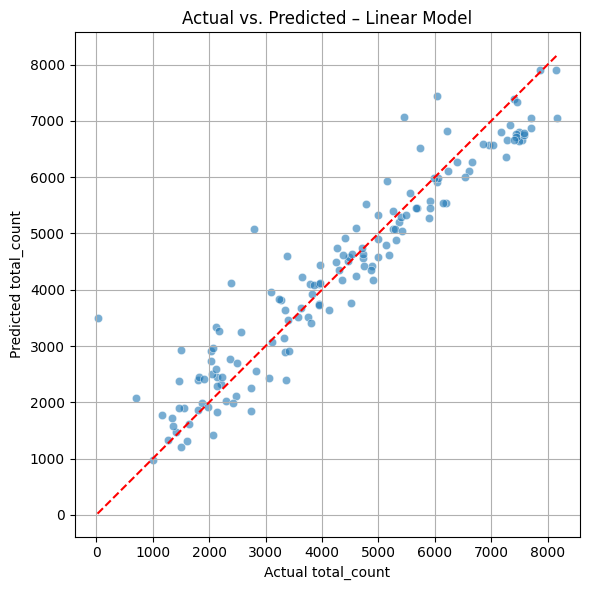

In [24]:
# Scatter plot of actual vs predicted values using Seaborn
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_lin, y=y_pred_lin, alpha=0.6)
# Add identity line (y = x) for reference
sns.lineplot(x=y_test_lin, y=y_test_lin, color='red', linestyle='--')
plt.xlabel('Actual total_count')
plt.ylabel('Predicted total_count')
plt.title('Actual vs. Predicted – Linear Model')
plt.grid(True)
plt.tight_layout()
plt.show()

**Note**:

The previous linear regression used forward stepwise selection, but some predictors may have nonlinear effects on the target, which linear models can’t capture well.

Thus, the following code adds degree-2 polynomial features to expand numerical variables, enabling the model to learn nonlinear and interaction effects, potentially improving predictions.

Total number of features after polynomial expansion and encoding: 39
Step 0: Null Model MSE = 3747654.56
Step 1: Added 'casual', CV MSE: 2654864.10
Step 2: Added 'workingday_1', CV MSE: 1640334.63
Step 3: Added 'year_1', CV MSE: 1041227.67
Step 4: Added 'casual^2', CV MSE: 649923.47
Step 5: Added 'season_4', CV MSE: 483022.70
Step 6: Added 'temperature', CV MSE: 444894.90
Step 7: Added 'weathersit_3', CV MSE: 425006.84
Step 8: Added 'weathersit_2', CV MSE: 414324.52
Step 9: Added 'month_7', CV MSE: 408447.20
Step 10: Added 'weekday_6', CV MSE: 404426.85
Step 11: Added 'weekday_4', CV MSE: 401631.34
Step 12: Added 'humidity windspeed', CV MSE: 398897.73
Step 13: Added 'weekday_3', CV MSE: 396156.68
Step 14: Added 'weekday_2', CV MSE: 392385.13
Step 15: Added 'month_3', CV MSE: 391300.49
Step 16: Added 'month_8', CV MSE: 391690.53
Step 17: Added 'month_10', CV MSE: 392217.24
Step 18: Added 'month_11', CV MSE: 387550.27
Step 19: Added 'holiday_1', CV MSE: 388849.30
Step 20: Added 'weekday

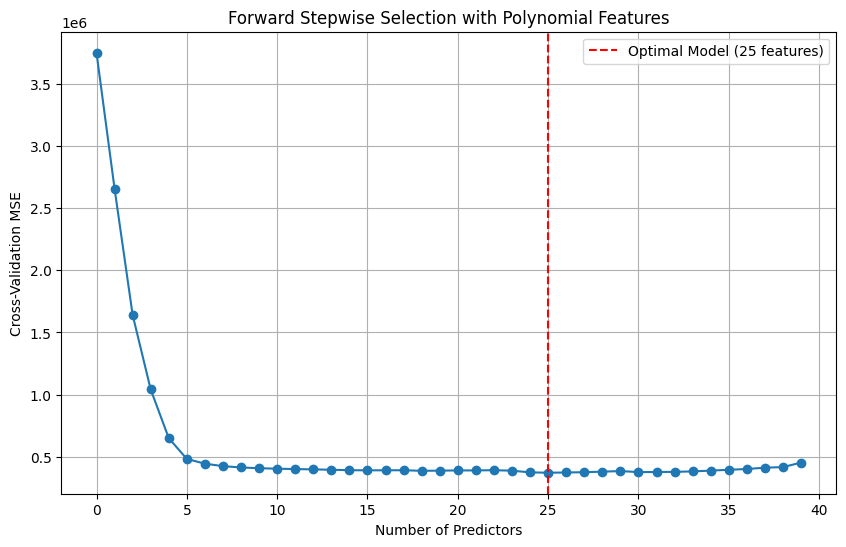

In [25]:
# --- 1. Data Preparation with Polynomial Features ---

# Drop columns that are not needed or would cause data leakage
df_model_poly = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')
X_poly = df_model_poly.drop('total_count', axis=1)
y_poly = df_model_poly['total_count']

# Define feature types
categorical_features_poly = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_poly = [col for col in X_poly.columns if col not in categorical_features_poly]


# Create a new pipeline for numerical features that first creates polynomial features
# and then scales them.
# Include_bias=False prevents adding a column of ones (the intercept is handled by LinearRegression).
numerical_pipeline_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Update the preprocessor to use the new numerical pipeline
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_poly, numerical_features_poly),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_poly)
    ],
    remainder='passthrough'
)

# Fit the preprocessor and get the complete list of new feature names
preprocessor_poly.fit(X_poly)
poly_names = preprocessor_poly.named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_poly)
ohe_names_poly = preprocessor_poly.named_transformers_['cat'].get_feature_names_out(categorical_features_poly)
all_names_poly = list(poly_names) + list(ohe_names_poly)

print(f"Total number of features after polynomial expansion and encoding: {len(all_names_poly)}")


# --- 2. Run Forward Stepwise Selection (using the same function as before) ---
# The function is called with the new preprocessor and the expanded feature list
history_df_poly, best_features_poly = forward_stepwise_selection(X_poly, y_poly, preprocessor_poly, all_names_poly, cv_folds=5)


# --- 3. Visualize Selection Process ---
plt.figure(figsize=(10, 6))
plt.plot(history_df_poly['num_features'], history_df_poly['cv_mse'], marker='o', linestyle='-')
best_num_features_poly = history_df_poly['cv_mse'].idxmin()
plt.axvline(x=best_num_features_poly, color='r', linestyle='--', label=f'Optimal Model ({best_num_features_poly} features)')
plt.xlabel('Number of Predictors')
plt.ylabel('Cross-Validation MSE')
plt.title('Forward Stepwise Selection with Polynomial Features')
plt.legend()
plt.grid(True)
plt.show()


--- Evaluating Final Polynomial Model on a Hold-Out Test Set ---
Features in the final model: ['casual', 'workingday_1', 'year_1', 'casual^2', 'season_4', 'temperature', 'weathersit_3', 'weathersit_2', 'month_7', 'weekday_6', 'weekday_4', 'humidity windspeed', 'weekday_3', 'weekday_2', 'month_3', 'month_8', 'month_10', 'month_11', 'holiday_1', 'weekday_5', 'weekday_1', 'temperature^2', 'season_3', 'season_2', 'month_4']
Test Set MSE: 352669.24
Test Set RMSE: 593.86
Test Set MAE: 420.07
Test Set R-squared (R²): 0.9120


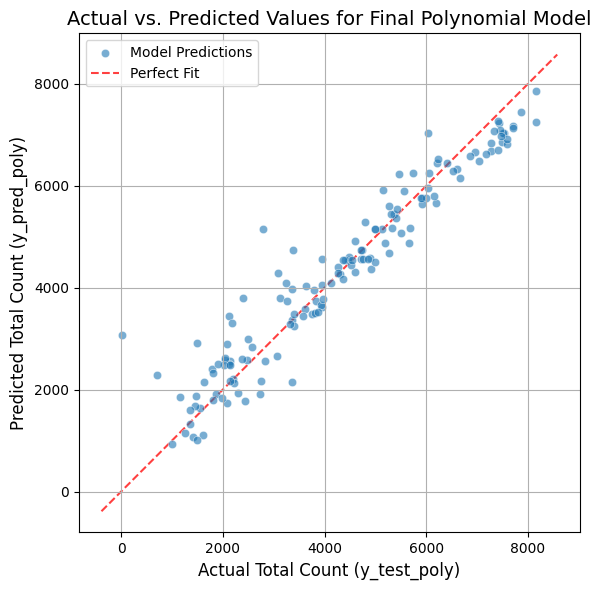

In [26]:
# --- 4. Final Model Evaluation on a Test Set ---
print("\n--- Evaluating Final Polynomial Model on a Hold-Out Test Set ---")
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

# Create the final pipeline with the best features identified
final_indices_poly = [all_names_poly.index(f) for f in best_features_poly]
final_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('selector', ColumnTransformer([('selector', 'passthrough', final_indices_poly)], remainder='drop')),
    ('regressor', LinearRegression())
])

final_pipeline_poly.fit(X_train_poly, y_train_poly)
y_pred_poly = final_pipeline_poly.predict(X_test_poly)
test_mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
test_mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)

print(f"Features in the final model: {best_features_poly}")
print(f"Test Set MSE: {test_mse_poly:.2f}")
print(f"Test Set RMSE: {np.sqrt(test_mse_poly):.2f}")
print(f"Test Set MAE: {test_mae_poly:.2f}")

# Calculate and print R-squared score
r2_poly = final_pipeline_poly.score(X_test_poly, y_test_poly)
print(f"Test Set R-squared (R²): {r2_poly:.4f}")


plt.figure(figsize=(6, 6))

# Create the scatter plot of actual vs. predicted values
sns.scatterplot(x=y_test_poly, y=y_pred_poly, alpha=0.6, label='Model Predictions')

# Add the line of perfect fit (y=x) for reference
# We find the min and max of the axes to draw a diagonal line across the plot
lims = [
    np.min([plt.gca().get_xlim(), plt.gca().get_ylim()]),
    np.max([plt.gca().get_xlim(), plt.gca().get_ylim()]),
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Fit')

# Set labels and title for clarity
plt.xlabel("Actual Total Count (y_test_poly)", fontsize=12)
plt.ylabel("Predicted Total Count (y_pred_poly)", fontsize=12)
plt.title("Actual vs. Predicted Values for Final Polynomial Model", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis('equal') # Ensures the x and y axes have the same scale for a proper 45-degree line
plt.tight_layout()
plt.show()

## 3.2 Ridge Regression 

--- Starting GridSearchCV for Ridge Regression ---
GridSearchCV finished. Best alpha found: 0.7565


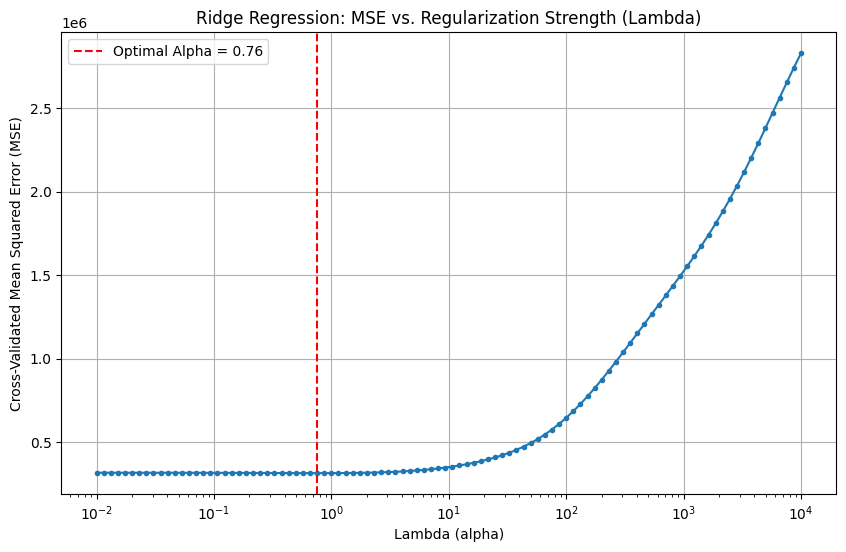


--- Calculating and plotting coefficient paths ---


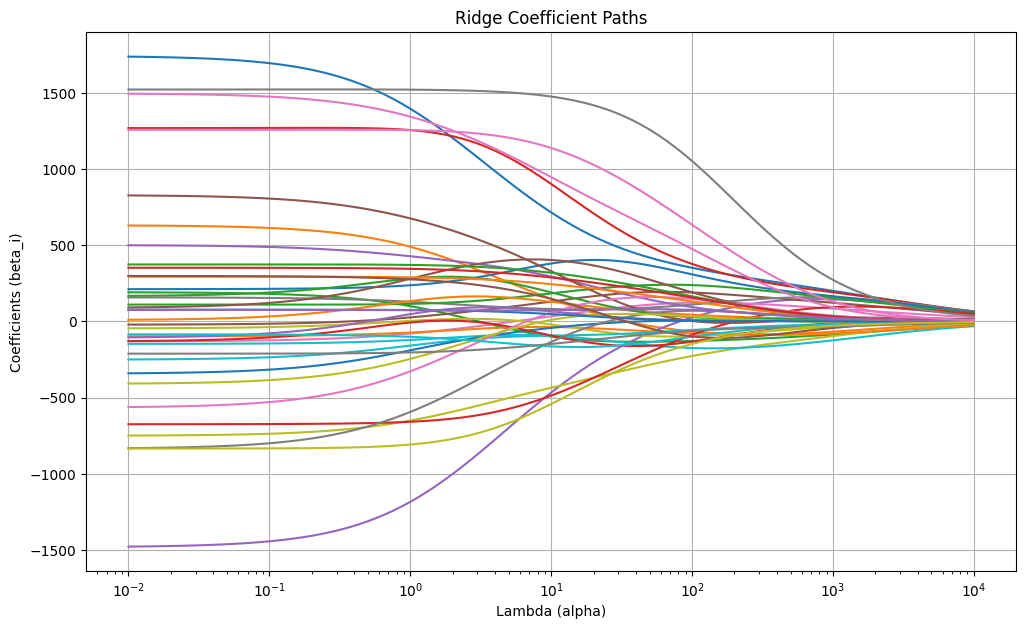


--- Training and Evaluating Final Model with Optimal Alpha: 0.7565 ---
Test Set MSE: 324942.42
Test Set RMSE: 570.04
Test Set MAE: 404.09
Test Set R-squared (R²): 0.9190


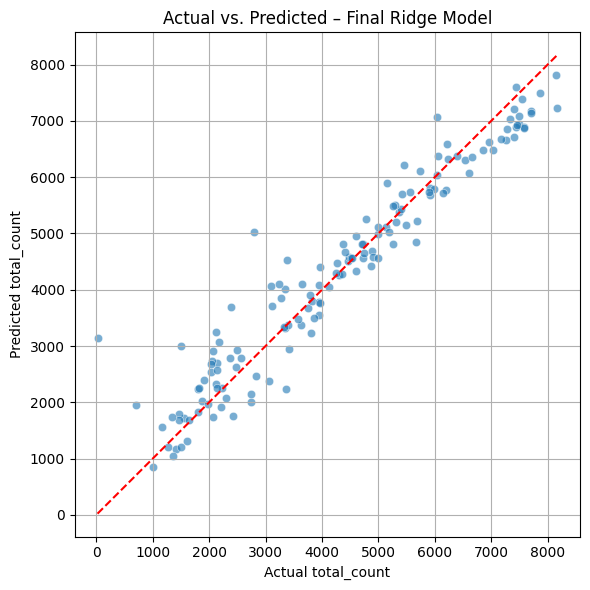


--- Coefficients of the Final Ridge Model ---


year_1                   1489.397529
casual                   1383.493294
temperature              1370.623156
season_4                 1322.530430
workingday_1             1285.610117
season_3                  596.787549
season_2                  411.642607
weekday_3                 389.950291
weekday_4                 352.211291
humidity                  297.543323
weekday_6                 282.407721
weekday_2                 276.862954
month_9                   236.751794
humidity casual           218.963854
month_6                   174.844996
weekday_1                 135.761451
windspeed casual          120.476889
weekday_5                  86.141802
temperature casual         85.469538
month_5                    52.824092
temperature humidity       27.656452
humidity windspeed         12.433303
windspeed                 -12.837534
month_2                   -23.180340
windspeed^2               -31.119486
holiday_1                 -44.682329
month_8                   -79.983888
t

In [27]:
# --- 1. Data and Pipeline Preparation ---

# Drop columns that are not needed or would cause data leakage
# Ensure 'humidity2' is dropped if it exists from previous cells
df_model_ridge = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')


# Define features (X) and target (y)
X_ridge = df_model_ridge.drop('total_count', axis=1)
y_ridge = df_model_ridge['total_count']

# Define feature types
categorical_features_ridge = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_ridge = [col for col in X_ridge.columns if col not in categorical_features_ridge]

# Create a pipeline for numerical features: PolynomialFeatures -> StandardScaler
numerical_pipeline_ridge = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create the main preprocessor
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_ridge, numerical_features_ridge),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_ridge)
    ],
    remainder='passthrough'
)

# Create the full pipeline with Ridge regression
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_ridge),
    ('ridge', Ridge())
])


# --- 2. Grid Search with Cross-Validation to find the best Lambda (Alpha) ---

# Define the grid of alpha values to search
# Using a logarithmic scale is common for regularization parameters
alphas = np.logspace(-2, 4, 100)

# Set up GridSearchCV
# The parameter to tune is 'ridge__alpha' (pipeline-step__parameter)
param_grid = {'ridge__alpha': alphas}
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

print("--- Starting GridSearchCV for Ridge Regression ---")
grid_search = GridSearchCV(ridge_pipeline, param_grid, cv=cv_strategy,
                           scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_ridge, y_ridge)

print(f"GridSearchCV finished. Best alpha found: {grid_search.best_params_['ridge__alpha']:.4f}")
best_alpha = grid_search.best_params_['ridge__alpha']


# --- 3. Visualization of Grid Search Results ---

# Plot 1: MSE vs. Lambda
# Shows how model error (MSE) changes with different regularization strengths to choose the best alpha.
plt.figure(figsize=(10, 6))
cv_mse = -grid_search.cv_results_['mean_test_score']
plt.plot(alphas, cv_mse, marker='.')
plt.xscale('log')
plt.axvline(best_alpha, linestyle='--', color='r', label=f'Optimal Alpha = {best_alpha:.2f}')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Cross-Validated Mean Squared Error (MSE)')
plt.title('Ridge Regression: MSE vs. Regularization Strength (Lambda)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 2: Coefficients as a function of Lambda (Coefficient Path)
# Visualizes how Ridge coefficients shrink smoothly under increasing regularization.
print("\n--- Calculating and plotting coefficient paths ---")
coefs = []
for a in alphas:
    ridge_pipeline.set_params(ridge__alpha=a)
    ridge_pipeline.fit(X_ridge, y_ridge)
    coefs.append(ridge_pipeline.named_steps['ridge'].coef_)

plt.figure(figsize=(12, 7))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Coefficients (beta_i)')
plt.title('Ridge Coefficient Paths')
plt.axis('tight')
plt.grid(True)
plt.show()


# --- 4. Final Model with Optimal Lambda ---

print(f"\n--- Training and Evaluating Final Model with Optimal Alpha: {best_alpha:.4f} ---")

# Split data into training and test sets
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(X_ridge, y_ridge, test_size=0.2, random_state=42)

# Create the final pipeline with the best alpha
final_ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_ridge),
    ('ridge', Ridge(alpha=best_alpha))
])

# Fit the model on the training data
final_ridge_pipeline.fit(X_train_ridge, y_train_ridge)

# Evaluate on the test data
y_pred_ridge = final_ridge_pipeline.predict(X_test_ridge)
test_mse_ridge = mean_squared_error(y_test_ridge, y_pred_ridge)
test_rmse_ridge = np.sqrt(test_mse_ridge)
test_mae_ridge = mean_absolute_error(y_test_ridge, y_pred_ridge) 
r2_ridge = final_ridge_pipeline.score(X_test_ridge, y_test_ridge)

print(f"Test Set MSE: {test_mse_ridge:.2f}")
print(f"Test Set RMSE: {test_rmse_ridge:.2f}")
print(f"Test Set MAE: {test_mae_ridge:.2f}")
print(f"Test Set R-squared (R²): {r2_ridge:.4f}")

# Plot 3: Scatter plot of actual vs predicted values using Seaborn
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_ridge, y=y_pred_ridge, alpha=0.6)
sns.lineplot(x=y_test_ridge, y=y_test_ridge, color='red', linestyle='--')  
plt.xlabel('Actual total_count')
plt.ylabel('Predicted total_count')
plt.title('Actual vs. Predicted – Final Ridge Model')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 5. Display Coefficients of the Final Model ---

# Get feature names from the preprocessor after it has been fitted
poly_feature_names = final_ridge_pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_ridge)
ohe_feature_names = final_ridge_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_ridge)
all_feature_names = list(poly_feature_names) + list(ohe_feature_names)

# Get the coefficients from the fitted ridge model
final_coefs = final_ridge_pipeline.named_steps['ridge'].coef_

# Create a pandas Series for better display
coef_series = pd.Series(final_coefs, index=all_feature_names)

print("\n--- Coefficients of the Final Ridge Model ---")
with pd.option_context('display.max_rows', None):
    display(coef_series.sort_values(ascending=False))

## 3.3 LASSO Regression

--- Starting GridSearchCV for Lasso Regression ---
GridSearchCV finished. Best alpha found: 0.4535


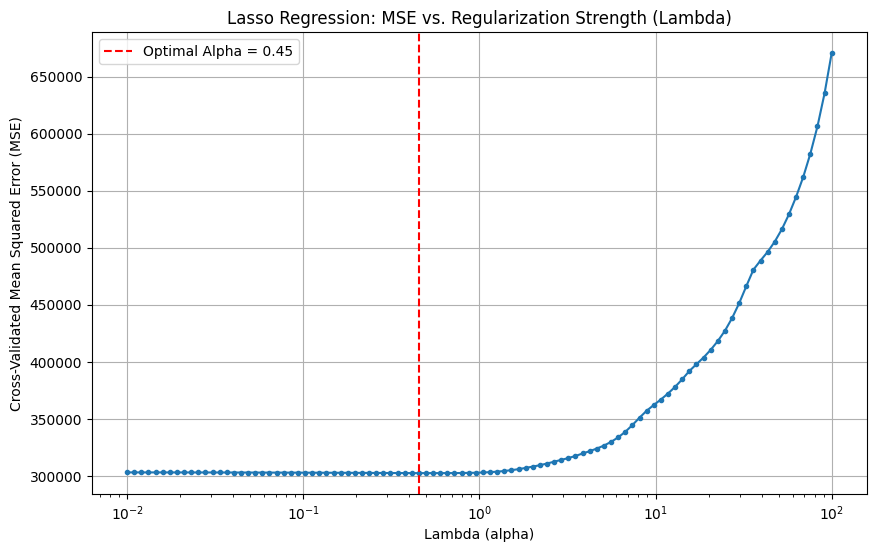


--- Calculating and plotting coefficient paths for Lasso ---


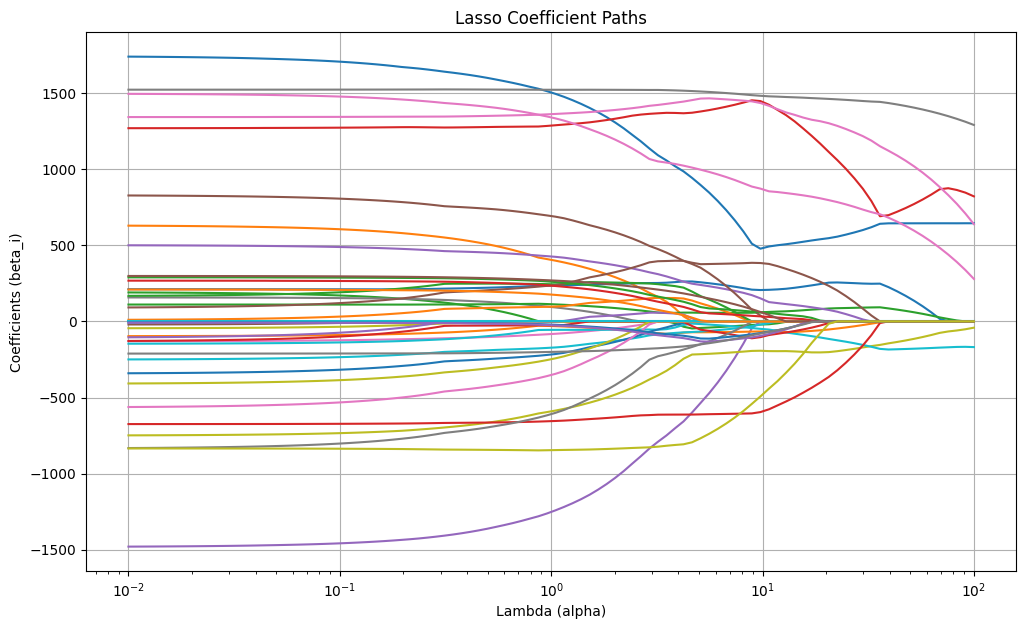

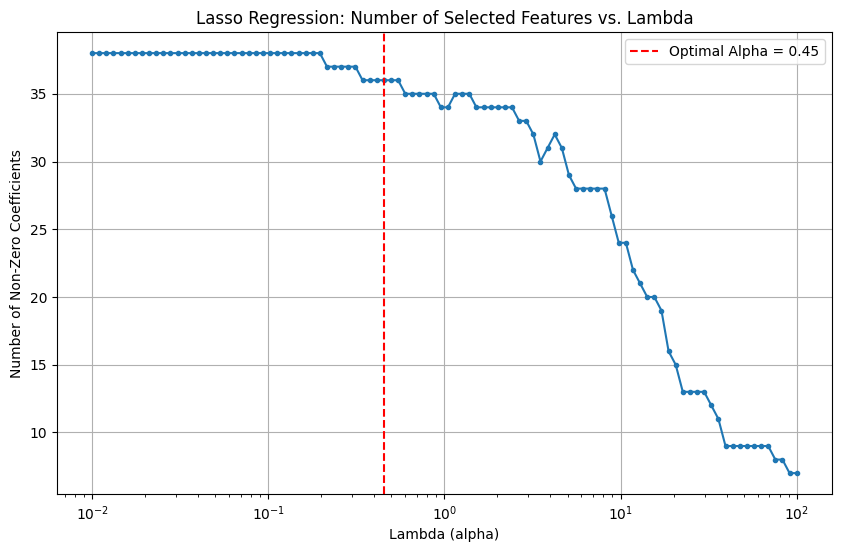


--- Training and Evaluating Final Lasso Model with Optimal Alpha: 0.4535 ---
Test Set MSE: 322174.25
Test Set RMSE: 567.60
Test Set MAE: 402.50
Test Set R-squared (R²): 0.9197


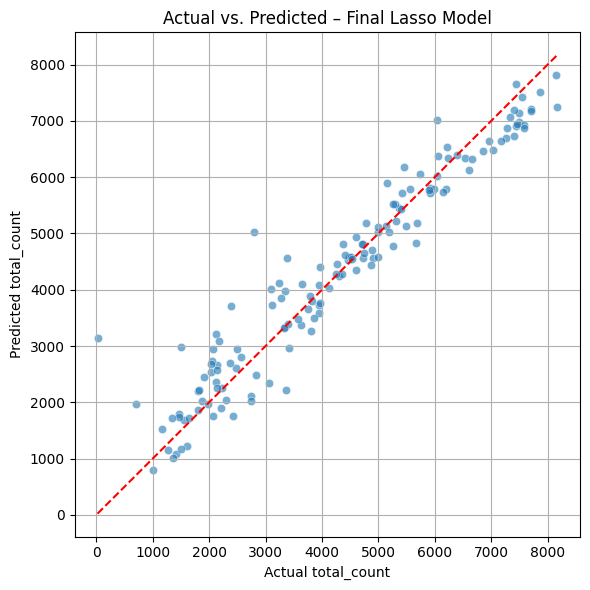


--- Coefficients of the Final Lasso Model (non-zero) ---


temperature              1553.724978
year_1                   1489.648164
casual                   1432.275376
workingday_1             1427.890721
season_4                 1388.228597
season_3                  656.069443
season_2                  439.366680
humidity                  313.891513
weekday_6                 289.624356
weekday_3                 248.655715
weekday_4                 213.844855
humidity casual           194.649412
month_9                   160.431600
weekday_2                 135.500809
month_6                   128.570936
windspeed casual          109.160680
holiday_1                  84.788203
temperature casual         81.919114
humidity windspeed         16.113239
windspeed^2               -26.389017
month_2                   -30.350158
weekday_5                 -49.546387
month_8                  -126.643883
temperature windspeed    -134.108451
month_7                  -166.951670
month_3                  -172.472610
weathersit_2             -212.125901
m

In [28]:
# --- 1. Data and Pipeline Preparation for Lasso ---

# Drop columns that are not needed or would cause data leakage
df_model_lasso = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant'], errors='ignore')
if 'humidity2' in df_model_lasso.columns:
    df_model_lasso = df_model_lasso.drop(columns=['humidity2'])

# Define features (X_lasso) and target (y_lasso)
X_lasso = df_model_lasso.drop('total_count', axis=1)
y_lasso = df_model_lasso['total_count']

# Define feature types
categorical_features_lasso = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_lasso = [col for col in X_lasso.columns if col not in categorical_features_lasso]

# Create a pipeline for numerical features: PolynomialFeatures -> StandardScaler
numerical_pipeline_lasso = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create the main preprocessor for Lasso
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_lasso, numerical_features_lasso),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_lasso)
    ],
    remainder='passthrough'
)

# Create the full pipeline with Lasso regression
# Increased max_iter to prevent convergence warnings with many features
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lasso),
    ('lasso', Lasso(max_iter=10000))
])


# --- 2. Grid Search with Cross-Validation to find the best Lambda (Alpha) ---

# Define the grid of alpha values to search
alphas_lasso = np.logspace(-2, 2, 100)

# Set up GridSearchCV for Lasso
param_grid_lasso = {'lasso__alpha': alphas_lasso}
cv_strategy_lasso = KFold(n_splits=10, shuffle=True, random_state=0)

print("--- Starting GridSearchCV for Lasso Regression ---")
grid_search_lasso = GridSearchCV(lasso_pipeline, param_grid_lasso, cv=cv_strategy_lasso,
                                 scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_lasso, y_lasso)

print(f"GridSearchCV finished. Best alpha found: {grid_search_lasso.best_params_['lasso__alpha']:.4f}")
best_alpha_lasso = grid_search_lasso.best_params_['lasso__alpha']


# --- 3. Visualization of Grid Search Results ---

# Plot 1: MSE vs. Lambda
# Shows how model error (MSE) changes with different regularization strengths to choose the best alpha.
plt.figure(figsize=(10, 6))
cv_mse_lasso = -grid_search_lasso.cv_results_['mean_test_score']
plt.plot(alphas_lasso, cv_mse_lasso, marker='.')
plt.xscale('log')
plt.axvline(best_alpha_lasso, linestyle='--', color='r', label=f'Optimal Alpha = {best_alpha_lasso:.2f}')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Cross-Validated Mean Squared Error (MSE)')
plt.title('Lasso Regression: MSE vs. Regularization Strength (Lambda)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 2: Coefficients as a function of Lambda (Coefficient Path)
# Shows how Lasso drives some coefficients to exactly zero as regularization increases.
print("\n--- Calculating and plotting coefficient paths for Lasso ---")
coefs_lasso = []
for a in alphas_lasso:
    lasso_pipeline.set_params(lasso__alpha=a)
    lasso_pipeline.fit(X_lasso, y_lasso)
    coefs_lasso.append(lasso_pipeline.named_steps['lasso'].coef_)

plt.figure(figsize=(12, 7))
ax = plt.gca()
ax.plot(alphas_lasso, coefs_lasso)
ax.set_xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Coefficients (beta_i)')
plt.title('Lasso Coefficient Paths')
plt.axis('tight')
plt.grid(True)
plt.show()

# Plot 3: Number of non-zero coefficients vs. Lambda
# Plot the number of non-zero coefficients to visualize Lasso's feature selection ability.
non_zero_coefs = [np.sum(np.abs(c) > 1e-6) for c in coefs_lasso]
plt.figure(figsize=(10, 6))
plt.plot(alphas_lasso, non_zero_coefs, marker='.')
plt.xscale('log')
plt.axvline(best_alpha_lasso, linestyle='--', color='r', label=f'Optimal Alpha = {best_alpha_lasso:.2f}')
plt.xlabel('Lambda (alpha)')
plt.ylabel('Number of Non-Zero Coefficients')
plt.title('Lasso Regression: Number of Selected Features vs. Lambda')
plt.legend()
plt.grid(True)
plt.show()


# --- 4. Final Model with Optimal Lambda ---

print(f"\n--- Training and Evaluating Final Lasso Model with Optimal Alpha: {best_alpha_lasso:.4f} ---")

# Split data into training and test sets
X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(X_lasso, y_lasso, test_size=0.2, random_state=42)

# Create the final pipeline with the best alpha
final_lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lasso),
    ('lasso', Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

# Fit the model on the training data
final_lasso_pipeline.fit(X_train_lasso, y_train_lasso)

# Evaluate on the test data
y_pred_lasso = final_lasso_pipeline.predict(X_test_lasso)
test_mse_lasso = mean_squared_error(y_test_lasso, y_pred_lasso)
test_rmse_lasso = np.sqrt(test_mse_lasso)
test_mae_lasso = mean_absolute_error(y_test_lasso, y_pred_lasso)
r2_lasso = final_lasso_pipeline.score(X_test_lasso, y_test_lasso)

print(f"Test Set MSE: {test_mse_lasso:.2f}")
print(f"Test Set RMSE: {test_rmse_lasso:.2f}")
print(f"Test Set MAE: {test_mae_lasso:.2f}")
print(f"Test Set R-squared (R²): {r2_lasso:.4f}")

# Plot 4: Scatter plot of actual vs predicted values using Seaborn
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_lasso, y=y_pred_lasso, alpha=0.6)
sns.lineplot(x=y_test_lasso, y=y_test_lasso, color='red', linestyle='--')
plt.xlabel('Actual total_count')
plt.ylabel('Predicted total_count')
plt.title('Actual vs. Predicted – Final Lasso Model')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 5. Display Coefficients of the Final Model ---

# Get feature names from the preprocessor after it has been fitted
poly_feature_names_lasso = final_lasso_pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['poly'].get_feature_names_out(numerical_features_lasso)
ohe_feature_names_lasso = final_lasso_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_lasso)
all_feature_names_lasso = list(poly_feature_names_lasso) + list(ohe_feature_names_lasso)

# Get the coefficients from the fitted lasso model
final_coefs_lasso = final_lasso_pipeline.named_steps['lasso'].coef_

# Create a pandas Series for better display
coef_series_lasso = pd.Series(final_coefs_lasso, index=all_feature_names_lasso)

print("\n--- Coefficients of the Final Lasso Model (non-zero) ---")
with pd.option_context('display.max_rows', None):
    display(coef_series_lasso[coef_series_lasso != 0].sort_values(ascending=False))

## 3.4 Random Forest Regression

--- Starting GridSearchCV for Random Forest ---
Fitting 7 folds for each of 144 candidates, totalling 1008 fits

GridSearchCV finished. Best parameters found: {'regressor__bootstrap': False, 'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 150}

--- Final Random Forest Model Performance ---
Test Set MSE: 361633.53
Test Set RMSE: 601.36
Test Set MAE: 421.80
Test Set R-squared (R²): 0.9098

--- Plotting Feature Importance ---


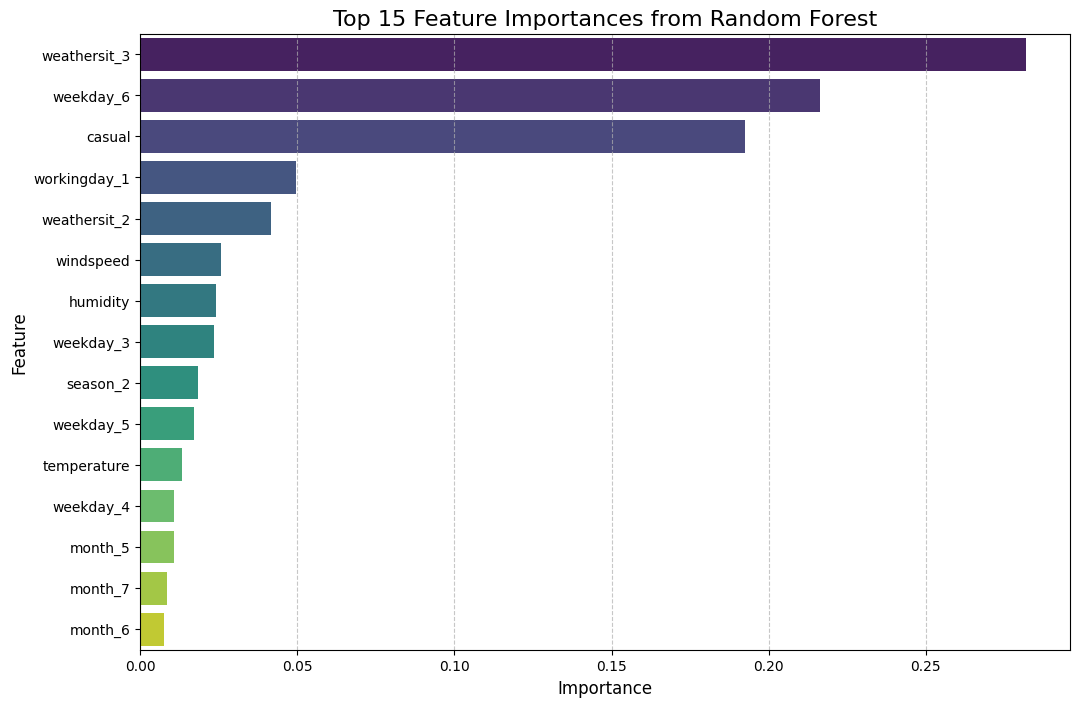

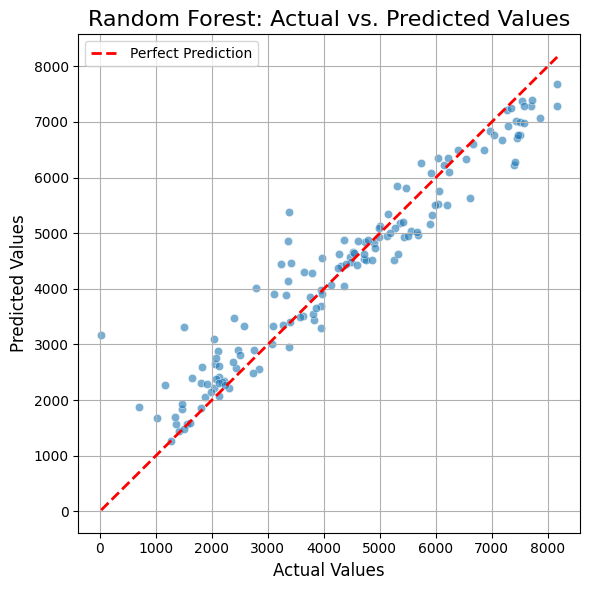

In [29]:
# Analyse Feature importance when applying decision tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. Data Preparation for Random Forest ---

# Use a clean copy of the dataframe
df_model_rf = day_bike.drop(columns=['date', 'registered', 'feeling_temperature', 'instant', 'humidity2'], errors='ignore')

# Define features (X_rf) and target (y_rf)
X_rf = df_model_rf.drop('total_count', axis=1)
y_rf = df_model_rf['total_count']

# Define feature types. For Random Forest, we only need to encode categorical features.
# Scaling numerical features is not necessary.
categorical_features_rf = ['season', 'year', 'month', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_features_rf = [col for col in X_rf.columns if col not in categorical_features_rf]

# Create a preprocessor that only one-hot encodes categorical features
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features_rf)
    ],
    remainder='passthrough'  # Keep numerical columns as they are
)


# --- 2. Pipeline and GridSearchCV Setup ---

# Create the full pipeline with the preprocessor and the RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Define a parameter grid for GridSearchCV. This is a small grid for demonstration.
# For a real project, you might want to explore a wider range of values.
param_grid_rf = {
    'regressor__n_estimators': [100, 150, 200],       # Number of trees in the forest
    'regressor__max_depth': [10, 20, None],      # Maximum depth of the tree
    'regressor__min_samples_leaf': [1, 2, 3, 5],       # Minimum number of samples required at a leaf node
    'regressor__max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'regressor__bootstrap': [True, False]  # Test with and without bootstrap sampling
}

# Set up the grid search with 5-fold cross-validation
cv_strategy_rf = KFold(n_splits=7, shuffle=True, random_state=42)

print("--- Starting GridSearchCV for Random Forest ---")
grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=cv_strategy_rf,
                              scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Split data before fitting the grid search to have a final hold-out test set
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

grid_search_rf.fit(X_train_rf, y_train_rf)

print(f"\nGridSearchCV finished. Best parameters found: {grid_search_rf.best_params_}")


# --- 3. Final Model Evaluation ---

# The best estimator is already fitted on the training data
final_rf_model = grid_search_rf.best_estimator_

# Make predictions on the test set
y_pred_rf = final_rf_model.predict(X_test_rf)

# Calculate final metrics
test_mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
test_rmse_rf = np.sqrt(test_mse_rf)
test_mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("\n--- Final Random Forest Model Performance ---")
print(f"Test Set MSE: {test_mse_rf:.2f}")
print(f"Test Set RMSE: {test_rmse_rf:.2f}")
print(f"Test Set MAE: {test_mae_rf:.2f}") 
print(f"Test Set R-squared (R²): {r2_rf:.4f}")


# --- 4. Visualization ---

# Plot 1: Feature Importance
print("\n--- Plotting Feature Importance ---")

# Get feature names after one-hot encoding
ohe_feature_names_rf = final_rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features_rf)
all_feature_names_rf = numerical_features_rf + list(ohe_feature_names_rf)

# Get importances from the trained model
importances = final_rf_model.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'feature': all_feature_names_rf, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(15) # Top 15 features

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis', hue='feature', legend=False)
plt.title('Top 15 Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


# Plot 2: Actual vs. Predicted Values
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_rf, y=y_pred_rf, alpha=0.6)
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], '--r', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('Random Forest: Actual vs. Predicted Values', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.legend() 
plt.show()

# 4. Model Evaluation  

Model Evaluation Strategy：

In this section, we evaluate the four regression models using four widely recognized metrics, each providing complementary insights into the model's performance:

- **MSE** (Mean Squared Error): Calculates the average squared errors, heavily penalizing large mistakes and being sensitive to outliers. Its units are squared, making it less intuitive than RMSE. 

- **RMSE** (Root Mean Squared Error): Also shares the same unit as the target variable but penalizes larger errors more heavily than MAE. It is useful for assessing whether the model remains robust under extreme conditions.

- **MAE** (Mean Absolute Error): Reflects the average magnitude of errors between predicted and actual values, expressed in the same unit as the target variable, making it highly interpretable. It is insensitive to outliers and suitable for scenarios where large errors are not severe.

- **R²** (Coefficient of Determination): Indicates the proportion of variance in the target variable explained by the model. As a unitless metric, it facilitates comparison between models and reflects the overall goodness of fit.

All these metrics are computed on the test set to assess the predictive accuracy and generalization ability of each model.

,Actual,Linear Regression,Ridge Regression,Lasso Regression,Random Forest
703,6606,6102.352190,6078.781381,6124.620062,5630.146667
33,1550,1898.627005,1720.887700,1687.096551,1562.400000
300,3747,3524.952327,3667.664855,3661.838812,3854.533333
456,6041,5922.801571,6032.731809,6024.352485,5526.820000
633,7538,6665.938435,7393.067379,7420.249609,7374.533333



--- Comparison of Model Metrics ---


,Model,MSE,RMSE,MAE,R-squared (R²)
0,Linear Regression,432461.351888,657.617938,479.581713,0.892151
1,Ridge Regression,324942.417585,570.037207,404.092812,0.918965
2,Lasso Regression,322174.248413,567.603954,402.499902,0.919655
3,Random Forest,361633.534692,601.359738,421.801723,0.909814


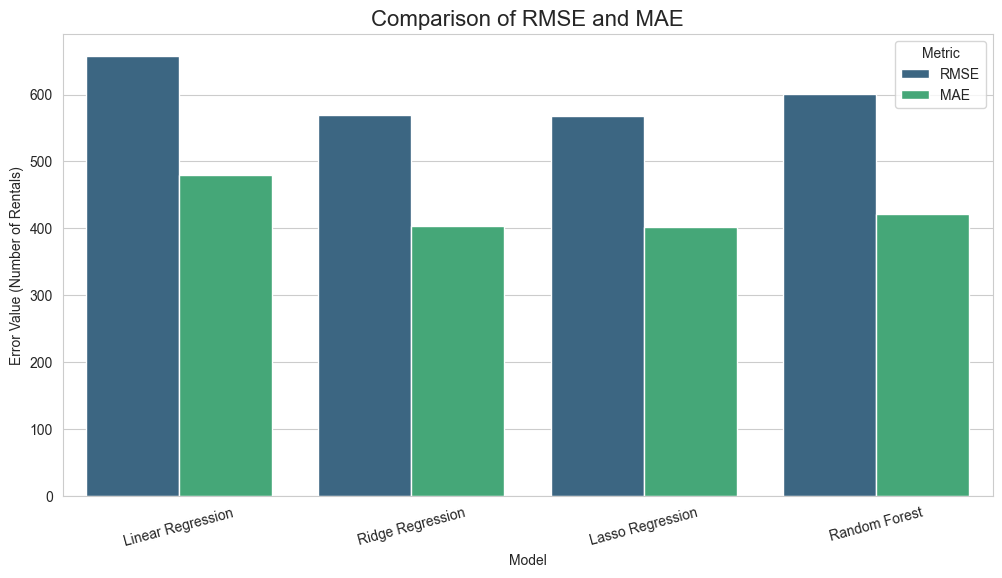

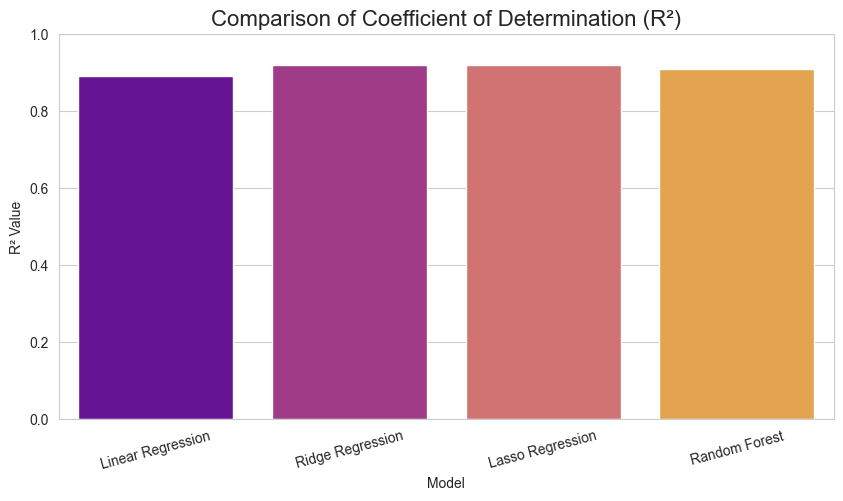

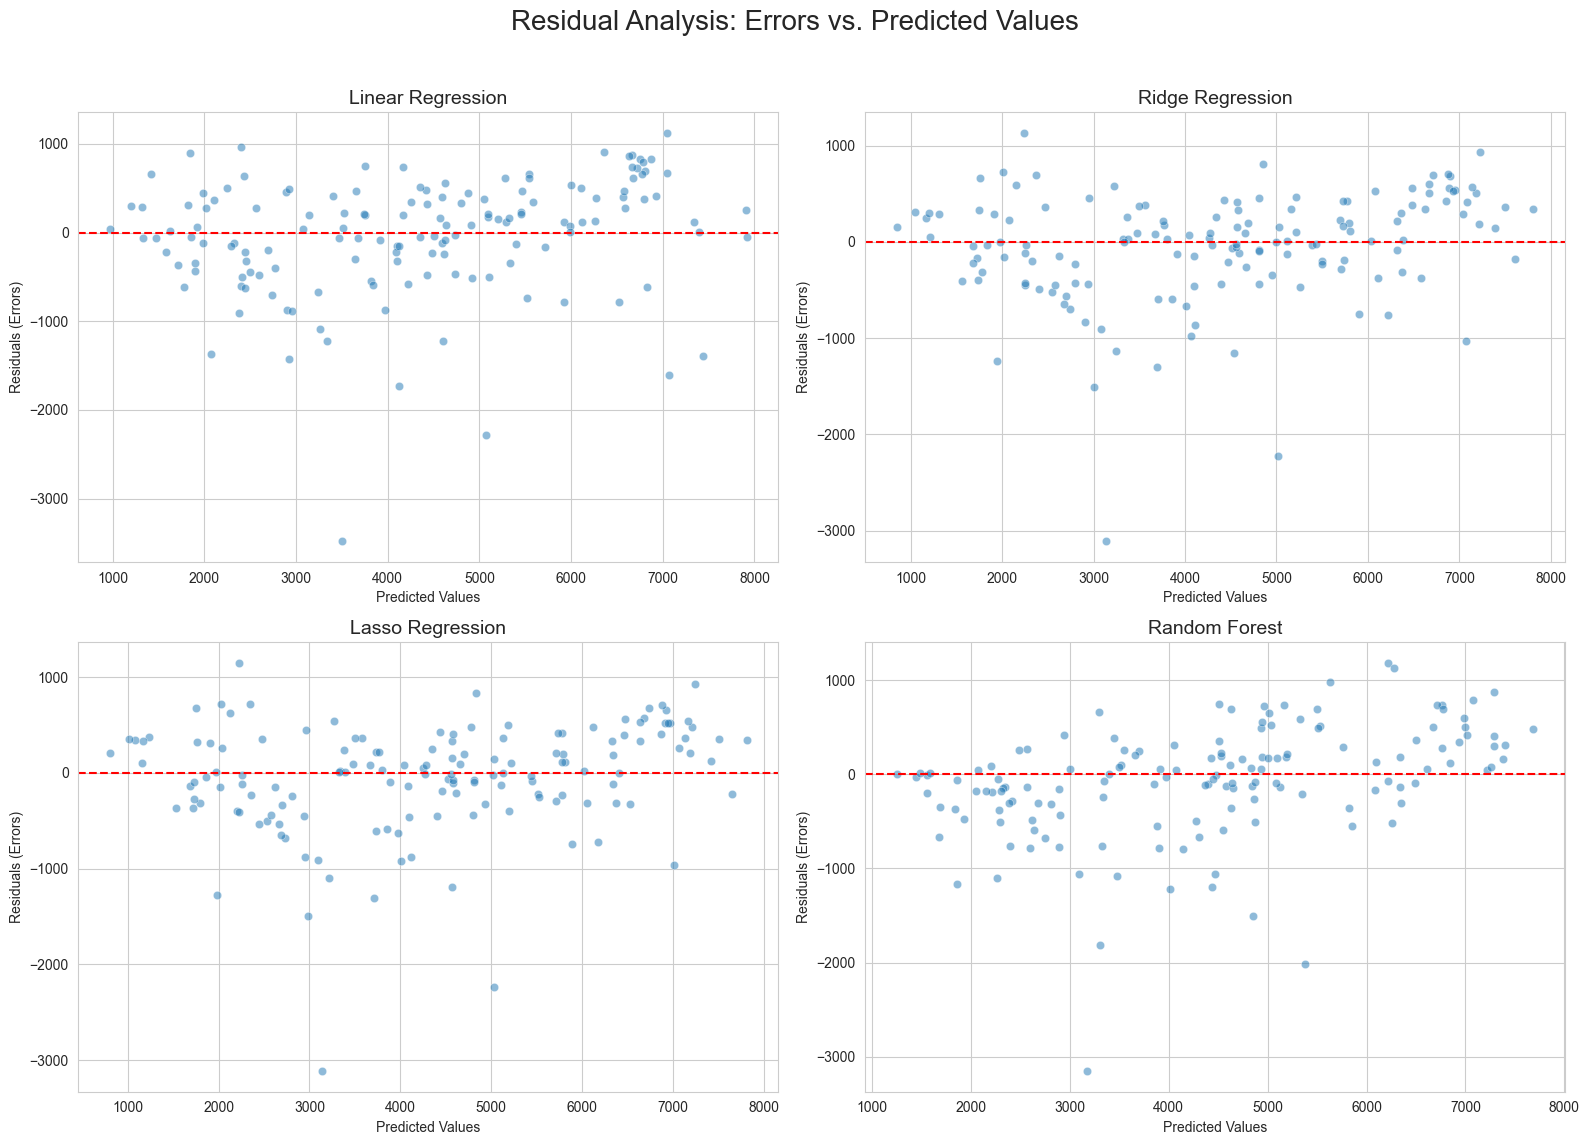

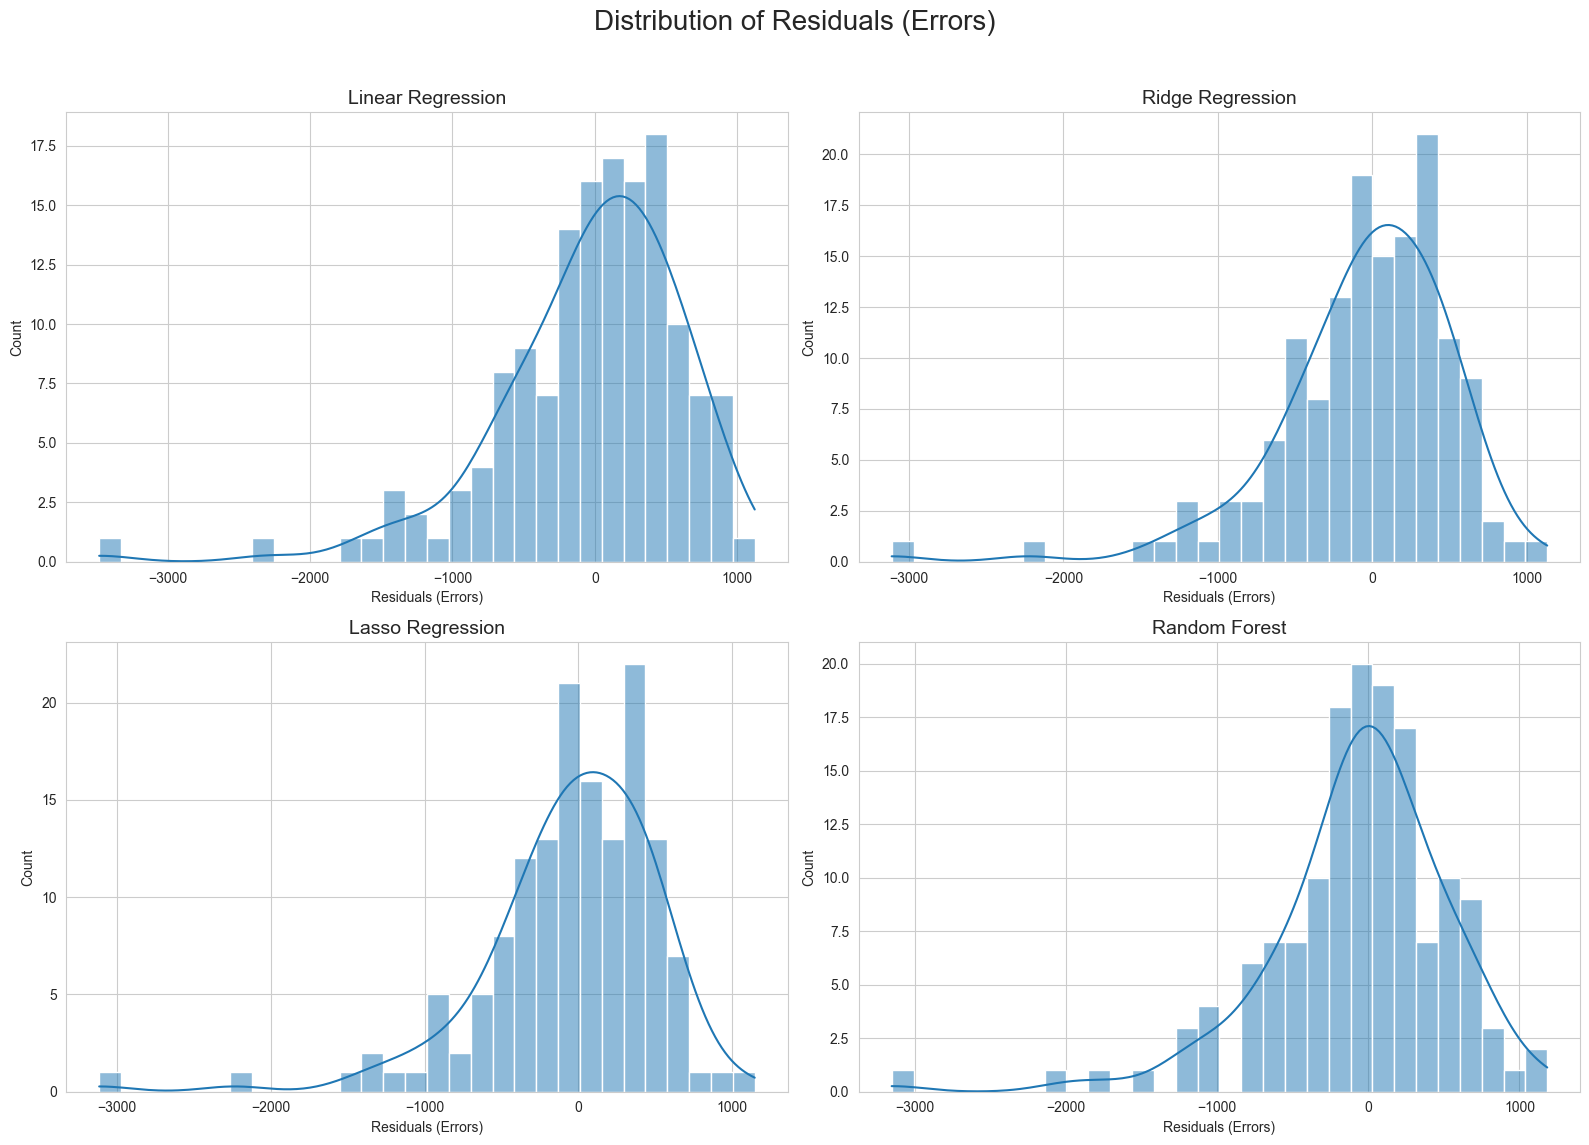

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 1. Collect results from all models ---

# Assumption: The final trained models and test data are available in memory.
# We use a unified test dataset for a fair comparison.
# (Assuming splits for all models are based on the same data)
X_test_final = X_test_rf  # or X_test_lasso, etc. - they should be identical
y_test_final = y_test_rf

# Create a dictionary with the final trained models
models = {
    "Linear Regression": final_pipeline_linear, # From Forward Selection
    "Ridge Regression": final_ridge_pipeline,
    "Lasso Regression": final_lasso_pipeline,
    "Random Forest": final_rf_model
}

# Create a DataFrame to store predictions
predictions_df = pd.DataFrame({'Actual': y_test_final})

# Make predictions for each model and add them to the DataFrame
for name, model in models.items():
    predictions_df[name] = model.predict(X_test_final)

display(predictions_df.head())


# --- 2. Calculate and compare numeric metrics ---

metrics_data = []
for name in models.keys():
    mse = mean_squared_error(predictions_df['Actual'], predictions_df[name])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(predictions_df['Actual'], predictions_df[name])
    r2 = r2_score(predictions_df['Actual'], predictions_df[name])
    metrics_data.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R-squared (R²)': r2
    })

metrics_df = pd.DataFrame(metrics_data)
print("\n--- Comparison of Model Metrics ---")
display(metrics_df)


# --- 3. Visualization of metrics ---

# Set plot style
sns.set_style("whitegrid")

# Melt the DataFrame for easier plotting with Seaborn
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

# Plot RMSE and MAE (errors on the same scale as the target variable)
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Value', hue='Metric', 
            data=metrics_melted[metrics_melted['Metric'].isin(['RMSE', 'MAE'])],
            palette='viridis')
plt.title('Comparison of RMSE and MAE', fontsize=16)
plt.ylabel('Error Value (Number of Rentals)')
plt.xticks(rotation=15)
plt.show()

# Plot R-squared
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Value',
            hue='Model', legend=False,
            data=metrics_melted[metrics_melted['Metric'] == 'R-squared (R²)'],
            palette='plasma')
plt.title('Comparison of Coefficient of Determination (R²)', fontsize=16)
plt.ylabel('R² Value')
plt.ylim(0, 1) # R² ranges between 0 and 1
plt.xticks(rotation=15)
plt.show()


# --- 4. Residual analysis visualization (error analysis) ---

# Calculate residuals for each model
for name in models.keys():
    predictions_df[f'{name}_Residuals'] = predictions_df['Actual'] - predictions_df[name]

# Plot residuals against predicted values
# This helps detect patterns in errors (e.g., whether the model performs worse at high values)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle('Residual Analysis: Errors vs. Predicted Values', fontsize=20)

for i, name in enumerate(models.keys()):
    sns.scatterplot(x=predictions_df[name], y=predictions_df[f'{name}_Residuals'], ax=axes[i], alpha=0.5)
    axes[i].axhline(0, ls='--', color='red')
    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('Predicted Values')
    axes[i].set_ylabel('Residuals (Errors)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# Plot distribution of residuals
# A good model should have errors that are normally distributed around zero.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle('Distribution of Residuals (Errors)', fontsize=20)

for i, name in enumerate(models.keys()):
    sns.histplot(predictions_df[f'{name}_Residuals'], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('Residuals (Errors)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# 5. Conclusion and Future Outlook

## 5.1 Conclusion

In our project, we developed predictive models to estimate daily bike rental counts using historical data from Washington D.C.’s Capital Bikeshare system. To achieve this, we preprocessed and analyzed the data and applied four different regression models:


- **LASSO Regression** achieved the **lowest MSE (322,174)**, **lowest RMSE (567.60)**, **lowest MAE (402.50)**, and the **highest R² score (0.920)**, making it the most accurate model.
  
- **Ridge Regression** performed nearly as well, with **R² score (0.919)** and **RMSE (570.04)**, highlighting the benefit of regularization in managing multicollinearity and improving generalization.
  
- **Random Forest Regression**, while nonlinear and flexible, did not outperform the regularized linear models. Its **R² score (0.910)** and **RMSE (601.36)** were slightly worse.
  
- **Linear Regression** was the least accurate, with the **lowest R² (0.892)** and **highest RMSE (657.62)**, indicating it was too simplistic to capture the complexity of the data.

  

---

## 5.2 Future Work

To further improve model performance and practical utility, the following directions could be considered:

- **Adding more features**  
  Including more information — public events, holidays, or public transport usage — might help the model understand what affects bike rentals        beyond just weather and season.

- **Time-based modeling**
  Bike rentals are highly seasonal and follow daily or weekly patterns. Using time series models like **ARIMA**, **Prophet**, or even simple **moving averages** could help capture those trends better.

- **Real-Time Prediction**  
  Integrate live weather and traffic feeds to enable dynamic, on-the-fly forecasting.

- **Deployment & Visualization**  
  Develop a user-friendly **dashboard or API** to support decision-making by city planners or bikeshare operators.



# 6. Sources

**[1]** Fanaee‑T, H., & Gama, J. (2013). _Event labeling combining ensemble detectors and background knowledge_. Progress in Artificial Intelligence, 1–15. Springer Berlin Heidelberg. https://doi.org/10.1007/s13748-013-0040-3
